# Fitting Bluetides UVLF
## Schecter and DPL Fitting

In [1]:
import glob
import corner
import sep

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import LogFormatterMathtext
from matplotlib import gridspec
import matplotlib.lines as mlines

import pandas as pd
import numpy as np
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.signal import fftconvolve
from scipy.stats import norm
from scipy.integrate import quad
from scipy.integrate import cumulative_trapezoid

from astropy.table import Table, vstack
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.convolution import convolve, Gaussian1DKernel
from astropy.nddata import block_reduce
from astropy.table.notebook_backends import ipydatagrid
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

from photutils.detection import find_peaks
import emcee

from bt_functions import grab_image, add_noise, plot_object, reduce, get_scale_pkpc, get_scale_as

In [2]:
# ------------------------------
# --- FORMATTING FIGURE TEXT ---
# ------------------------------
mpl.rcParams.update({
    "font.family": "cm",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "mathtext.rm": "serif",
    "mathtext.it": "serif:italic",
    "mathtext.bf": "serif:bold",
    "axes.labelsize": 18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "axes.titlesize": 18
})

In [3]:
# ---------------------------
# -------- LOAD DATA --------
# ---------------------------
redshift = 7

bluetides_path = '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_*/hlsp_bluetides_jwst_nircam_z{redshift}*_f*w_v1_sim-*.fits'
img_path = '/Volumes/SeagateBack/bluetides/plots'
code_path = '/Volumes/SeagateBack/bluetides/code'

filenames = glob.glob(bluetides_path.format(redshift=redshift))       # finds all files in path with given format 
print("Number of files:",len(filenames))                              # there are 56 files in total for z=7

catalog = Table.read('/Volumes/SeagateBack/bluetides/code/hlsp_bluetides_multi_multi_all_multi_v2_sim.csv')
if 'id' in catalog.colnames:
    catalog.replace_column('id', 1 + np.arange(len(catalog)))
else:
    catalog.add_column(1 + np.arange(len(catalog)), name='id', index=0)

catalog[:10]

Number of files: 56


id,col0,redshift,fileNumber,extensionNumber,stellarMass,BHmass,BHluminosity,haloMass,lum_FUV,flux_jwst.nircam.f090w,radius_jwst.nircam.f090w,flux_jwst.nircam.f115w,radius_jwst.nircam.f115w,flux_jwst.nircam.f150w,radius_jwst.nircam.f150w,flux_jwst.nircam.f200w,radius_jwst.nircam.f200w,flux_jwst.nircam.f277w,radius_jwst.nircam.f277w,flux_jwst.nircam.f356w,radius_jwst.nircam.f356w,flux_jwst.nircam.f410m,radius_jwst.nircam.f410m,flux_jwst.nircam.f444w,radius_jwst.nircam.f444w,flux_jwst.miri.f560w,radius_jwst.miri.f560w,flux_jwst.miri.f770w,radius_jwst.miri.f770w,flux_hst.wfc3.f105w,radius_hst.wfc3.f105w,flux_hst.wfc3.f125w,radius_hst.wfc3.f125w,flux_hst.wfc3.f140w,radius_hst.wfc3.f140w,flux_hst.wfc3.f160w,radius_hst.wfc3.f160w,flux_euclid.nisp.y,radius_euclid.nisp.y,flux_euclid.nisp.j,radius_euclid.nisp.j,flux_euclid.nisp.h,radius_euclid.nisp.h,flux_roman.wfi.f087,radius_roman.wfi.f087,flux_roman.wfi.f106,radius_roman.wfi.f106,flux_roman.wfi.f129,radius_roman.wfi.f129,flux_roman.wfi.f146,radius_roman.wfi.f146,flux_roman.wfi.f158,radius_roman.wfi.f158,flux_roman.wfi.f184,radius_roman.wfi.f184,flux_subaru.hsc.z,radius_subaru.hsc.z,flux_subaru.hsc.y,radius_subaru.hsc.y,flux_vista.vircam.z,radius_vista.vircam.z,flux_vista.vircam.y,radius_vista.vircam.y,flux_vista.vircam.j,radius_vista.vircam.j,flux_vista.vircam.h,radius_vista.vircam.h,flux_vista.vircam.ks,radius_vista.vircam.ks,flux_spitzer.irac.ch1,flux_spitzer.irac.ch2
int64,int64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0,7.0,1,1,62058380000.0,374432960.0,9.854875355041004e+46,1292328500000.0,1.2920170160111174e+29,23.11590576171875,1.2503641843795776,169.21633911132812,1.1419026851654053,186.37940979003906,1.058977723121643,195.3888702392578,0.99473637342453,261.0684814453125,0.893967866897583,470.4862060546875,0.8837507963180542,635.4224243164062,0.8629537224769592,543.959228515625,0.8785976767539978,623.2904052734375,1.012123703956604,682.6275024414062,1.0523561239242554,125.1771011352539,1.2744066715240479,175.79356384277344,1.2591437101364136,183.14561462402344,1.2591437101364136,188.14297485351562,1.2591437101364136,183.15052795410156,1.7575469017028809,221.62730407714844,1.7575469017028809,227.99705505371094,1.6979515552520752,9.006768226623535,1.2672045230865479,129.13966369628906,1.2562328577041626,178.63833618164062,1.233996868133545,171.67251586914062,1.233996868133545,189.06185913085938,1.2227272987365723,192.5867462158203,1.233996868133545,13.57265567779541,2.1514832973480225,81.3726806640625,2.182002305984497,48.2589225769043,2.300032377243042,212.34750366210938,2.300032377243042,218.61846923828125,2.2417943477630615,241.94602966308594,2.2417943477630615,243.62803649902344,2.2417943477630615,503.7591247558594,553.727783203125
2,1,7.0,1,2,129293664000.0,365300220.0,9.614507498709602e+46,8704022300000.0,6.276021859962179e+29,104.62671661376953,1.5874279737472534,813.4927978515625,1.5317360162734985,980.5615234375,1.4836066961288452,1121.8316650390625,1.4498753547668457,1516.3748779296875,1.3743971586227417,2676.136962890625,1.3842731714248657,3508.948974609375,1.4421098232269287,3085.17578125,1.3842731714248657,3377.263916015625,1.4975289106369019,3822.9365234375,1.4882562160491943,595.3988037109375,1.5608230829238892,861.0501708984375,1.5608230829238892,931.8605346679688,1.5608230829238892,1000.8505859375,1.5608230829238892,1080.4014892578125,2.313918113708496,1379.1951904296875,2.313918113708496,1548.9696044921875,2.357996702194214,37.4470329284668,1.5872795581

In [4]:
# --------------------------------------------------------------
# --- REPLACE LUM FUV COLUMN IN ALL TABLES USING NEW CATALOG ---
# --------------------------------------------------------------
f150w_Table = Table.read(f'{code_path}/sep_table_f150w.ecsv')

lum_map = {row['id']: row['lum_FUV'] for row in catalog}

def replace_luminosity(table, lum_map):
    table_ids = table['id'].astype(int)
    table['lumFUV'] = [lum_map.get(i, np.nan) for i in table_ids]
    return table

f150w_Table = replace_luminosity(f150w_Table, lum_map)

# ----------------------------------------
# --- ADD DISTANCE COLS IN PKPC AND AS ---
# ----------------------------------------

unique_ids = np.unique(f150w_Table['id'])
scale_pkpc = {}
scale_as = {}

for id in unique_ids:
    try:
        scale_pkpc[id] = get_scale_pkpc(id, filter='f150w', redshift=7, catalog=catalog, filenames=filenames)
        scale_as[id] = get_scale_as(id, filter='f150w', redshift=7, catalog=catalog, filenames=filenames)
    except:
        print(f"Could not load scale for id={id}")


# Map ID → scale, then broadcast
f150w_Table['distance_pkpc'] = [
    scale_pkpc[row['id']] * row['distances'] 
    for row in f150w_Table
]
f150w_Table['distance_as'] = [
    scale_as[row['id']] * row['distances'] 
    for row in f150w_Table
]
f150w_Table


id,haloMass,bhMass,stellarMass,lumFUV,convolution,distances,flux_ratio,area_1,area_2,has_psf,distance_pkpc,distance_as
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,float64,float64
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.0,5.8341918239615005,0.5927456669607006,50.0,60.0,False,0.4849058196688117,0.09042997327140326
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.5,11.315334820295579,0.2710036965865495,48.0,115.0,False,0.9404681696147605,0.17538768971458146
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,1.0,4.458249248190907,0.47129277006608244,85.0,176.0,False,0.37054506797377823,0.06910286334695906
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,2.0,0.0,0.0,0.0,0.0,False,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,5.0,0.0,0.0,0.0,0.0,False,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.0,0.0,0.0,0.0,0.0,True,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.5,0.0,0.0,0.0,0.0,True,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,1.0,0.0,0.0,0.0,0.0,True,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,2.0,0.0,0.0,0.0,0.0,True,0.0,0.0


### Stats of flux_ratio:

In [87]:
flux_ratio_mask = (f150w_Table['flux_ratio'] > 0) & (f150w_Table['convolution'] == 0.0) & (f150w_Table['has_psf'] == False)

median = np.median(f150w_Table['flux_ratio'][flux_ratio_mask])
stddev = np.std(f150w_Table['flux_ratio'][flux_ratio_mask])

print(median, stddev)

0.5115208082549381 0.263288467715902


redshift= 7
number of galaxies= 71052

redshift= 8
number of galaxies= 22144

redshift= 9
number of galaxies= 5606



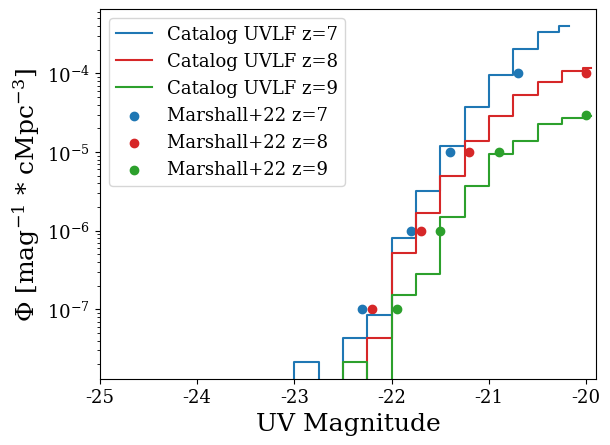

In [5]:
# --- BLUETIDES UVLF FOR REDSHIFT 7-9 ---

plt.rcParams['mathtext.fontset'] = 'cm'        # Computer Modern math font
plt.rcParams['font.family'] = 'serif'          # Use serif for all non-math text
plt.rcParams['font.serif'] = ['CMU Serif', 'DejaVu Serif']

plt.rcParams['axes.unicode_minus'] = False     # Proper minus signs
plt.rcParams['mathtext.default'] = 'regular'   # Consistent regular math font


# VOLUME
h = 0.7
L_box = 400 / h     # box length
V_box = L_box**3    # box volume

# REDSHIFTS TO PLOT
redshifts = [7, 8, 9]
colors = ['tab:blue', 'tab:red', 'tab:green']

fig, ax = plt.subplots()

bin_width = 0.25

# PLOT UVLF BY REDSHIFT
uvlf_dict = {}

for i, z in enumerate(redshifts):

    mask = (catalog['redshift'] == z)
    print("redshift=", z)
    print('number of galaxies=', len(catalog[mask]))
    print()

    lum_FUV = np.log10(catalog['lum_FUV'][mask])
    M_FUV = 51.63 - 2.5 * lum_FUV

    # --- Define cutoff ---
    cutoff = -20.1 if z == 7 else -19.9

    # --- Build bins ---
    # last regular edge just below cutoff
    last_edge = np.floor(cutoff / bin_width) * bin_width

    bins_regular = np.arange(-23.75, last_edge + bin_width, bin_width)
    bins_M = np.append(bins_regular, cutoff)

    # --- Derived quantities ---
    bin_centers_M = 0.5 * (bins_M[:-1] + bins_M[1:])
    bin_widths = np.diff(bins_M)

    # --- UVLF ---
    N_M, _ = np.histogram(M_FUV, bins=bins_M)
    phi_M = N_M / (V_box * bin_widths)
    phi_err_M = np.sqrt(N_M) / (V_box * bin_widths)

    uvlf_dict[z] = {
        'bin_centers': bin_centers_M,
        'N_M': N_M,
        'phi_M': phi_M,
        'phi_err_M': phi_err_M
    }

    # --- Plot ---
    ax.step(
        bin_centers_M,
        phi_M,
        where='mid',
        label=f'Catalog UVLF z={z}',
        color=colors[i]
    )

# Points taken from Marshall et al 2022, Figure 1:
ax.scatter([-20.7, -21.4, -21.8, -22.3], [1e-4,1e-5,1e-6,1e-7], color='tab:blue',  label='Marshall+22 z=7')   
ax.scatter([-20, -21.2, -21.7, -22.2],   [1e-4,1e-5,1e-6,1e-7], color='tab:red',   label='Marshall+22 z=8')   
ax.scatter([-20, -20.9, -21.5, -21.95],  [3e-5,1e-5,1e-6,1e-7], color='tab:green', label='Marshall+22 z=9')  

ax.set_xlim(-25,-19.9)
ax.set_yscale('log')
ax.set_xlabel("UV Magnitude")
ax.set_ylabel(r"$\Phi$ [mag$^{-1}$ * cMpc$^{-3}$]")
ax.legend()

plt.show()


In [6]:
# Create a set of known pair indices to define ground truth
# By-eye pairs
pair_indices = {
    2, 8, 13, 17, 19, 25, 27, 33, 37, 38, 41, 57, 62, 64, 72, 76, 79, 87, 88, 90,
    93, 94, 95, 97, 98, 99, 105, 107, 109, 112, 117, 128, 136, 147, 167, 171, 184,
    191, 199, 201, 204, 209, 217, 228, 233, 285, 311, 326, 330, 332, 344, 357, 364,
    385, 388, 396, 402, 405, 407, 433, 456, 469, 472, 494, 504, 511, 523, 530, 556,
    559, 568, 616, 617, 625, 640, 641, 650, 657, 664, 669, 678, 681, 683, 727, 729,
    745, 749, 760, 773, 794, 800, 802, 814, 821, 830, 845, 850, 852, 870, 879, 903,
    915, 919, 954, 987, 997
}

# Create arrays for pairs and non-pairs under 1000
all_indices = set(range(1000))
non_pairs = sorted(all_indices - pair_indices)
print(len(pair_indices)/1000)
pairs = sorted(pair_indices)

0.106


Found a bug in cell below - 10/90 and 50/50 were too long (was adding two daughter galaxies and parent galaxy to list)

/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_71914/557448688.py:155: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  uvlf = ax.errorbar(


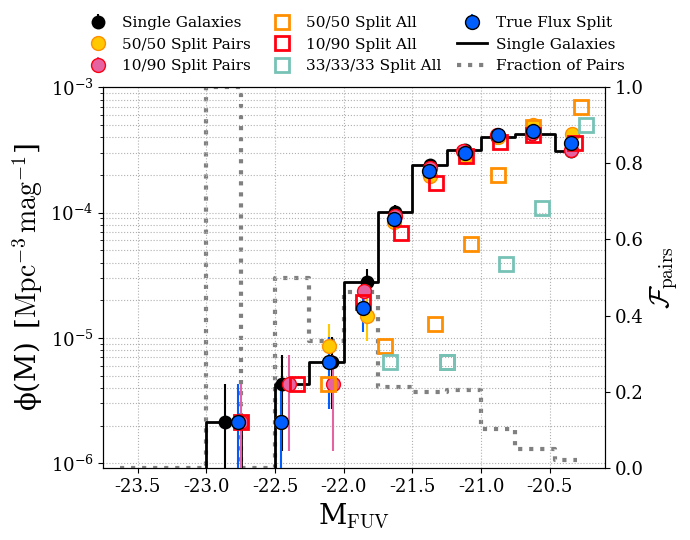

In [ ]:
# ============================================================ #
#           GLOBAL FONT SETTINGS (Math Font Everywhere)        #
# ============================================================ #

plt.rcParams['mathtext.fontset'] = 'cm'        # Computer Modern math font
plt.rcParams['font.family'] = 'serif'          # Use serif for all non-math text
plt.rcParams['font.serif'] = ['CMU Serif', 'DejaVu Serif']

plt.rcParams['axes.unicode_minus'] = False     # Proper minus signs
plt.rcParams['mathtext.default'] = 'regular'   # Consistent regular math font

# ================================================ #
#   FUV Luminosity Function + Fraction of Pairs    #
# ================================================ #

df = f150w_Table.copy()
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False) & (df['convolution'] == 0.0)

# ----- Select GT from Catalog -----
mask_nopsf = ((df['has_psf'] == False) & (df['convolution'] == 0.0))
lum_FUV = df[mask_nopsf]['lumFUV']

# ----- Split Luminosity for Pair Galaxies -----
lum_sets = {
    'single': [], 
    '5050_pairs': [], '1090_pairs': [],
    '5050_all': [], '1090_all': [], 
    '33_all': [],
    'split': [],
    }

for row in df[mask_nopsf]:

    lum_sets['single'].append(row['lumFUV'])

    # SPLITTING WHOLE SAMPLE    
    lum_sets['5050_all'].extend([row['lumFUV'] * 0.5, row['lumFUV'] * 0.5]) # 50/50 flux split
    lum_sets['1090_all'].extend([row['lumFUV'] * 0.1, row['lumFUV'] * 0.9]) # 10/90 flux split
    lum_sets['33_all'].extend([row['lumFUV'] * 0.33, row['lumFUV'] * 0.33, row['lumFUV'] * 0.33]) # 33/33/33 flux split

    # SPLITTING ONLY PAIRS
    if row['is_pair']:
        lum_sets['split'].extend([
            row['lumFUV'] * row['flux_ratio'],
            row['lumFUV'] * (1 - row['flux_ratio'])
        ])
        lum_sets['5050_pairs'].extend([row['lumFUV'] * 0.5, row['lumFUV'] * 0.5])
        lum_sets['1090_pairs'].extend([row['lumFUV'] * 0.1, row['lumFUV'] * 0.9])

    else:
        lum_sets['split'].append(row['lumFUV'])
        lum_sets['5050_pairs'].append(row['lumFUV'])
        lum_sets['1090_pairs'].append(row['lumFUV'])

# ----- Convert luminosity to magnitude -----
M_FUV = {}
for key, lum_values in lum_sets.items():
    lum_log = np.log10(lum_values)
    M_FUV[key] = 51.63 - 2.5 * lum_log

# ----- Volume of sample ----- 
len_sample = np.sum(mask_nopsf)
len_catalog = len(catalog)
h = 0.7
L_box = 400 / h
V_box = L_box**3
V_eff = V_box * (len_sample / len_catalog)

# ----- Construct bins -----
bin_width = 0.25
bin_phase = 0

M_min = -23.75
M_max = -20.25
mag_cutoff = -20.1

bins_regular = np.arange(M_min, M_max, bin_width)  # magnitude bins width 0.25
bins_M = np.append(bins_regular, mag_cutoff)
bin_centers_M = 0.5 * (bins_M[:-1] + bins_M[1:])
bin_width_M = bins_M[1] - bins_M[0]

# ----- Compute bin median magnitudes -----
median_key = 'single'   # to compute medians consistently

# ----- Calculate UVLF -----
phi_M = {}
phi_err_M = {}

labels = {
    'single': 'Single Galaxies', 'split': 'True Flux Split',
    '5050_all': '50/50 Split All', '1090_all': '10/90 Split All', '33_all': '33/33/33 Split All',
    '5050_pairs': '50/50 Split Pairs', '1090_pairs': '10/90 Split Pairs'
}
mfc = {
    'single': 'k', 'split': '#005EFF',
    '5050_all':'None',  '1090_all': 'None', '33_all': 'None',
    '5050_pairs': '#FFC800', '1090_pairs': '#E663A2',
}
mec = {
    'single': 'None', 'split': 'k',
    '5050_all': "#FF8E00", '1090_all': "#FF0011", '33_all': '#77C2B5',
    '5050_pairs': "#FF8E00", '1090_pairs': "#FF0011"
}
markers = {
    'single': 'o', 'split': 'o',
    '5050_all': 's', '1090_all': 's', '33_all': 's',
    '5050_pairs': "o", '1090_pairs': "o"
}
linestyles = {
    'single': '-', 'split': '-', 
    '5050_all': '--', '1090_all': '--'
    }
linewidths = {
    'single': 2, 'split': 1, 
    '5050_all': 2, '1090_all': 2, '33_all': 2,
    '5050_pairs': 1, '1090_pairs': 1
    }

# ----- Fraction of pairs -----
mask_pairs = df[mask_nopsf]['is_pair']
M_single = M_FUV['single']
fraction_pairs = []

for i in range(len(bins_M)-1):
    bin_mask = (M_single >= bins_M[i]) & (M_single < bins_M[i+1])
    if np.sum(bin_mask) > 0:
        fraction_pairs.append(np.mean(mask_pairs[bin_mask]))
    else:
        fraction_pairs.append(0.0)

# ----- Plot UVLF + Pair Fractions -----
fig, ax = plt.subplots(figsize=(7, 5.5))

bin_widths = np.diff(bins_M)

legend_handles = []
for key in lum_sets.keys():
    bin_medians = []
    M_vals = M_FUV[key]

    for i in range(len(bins_M)-1):
        mask = (M_vals >= bins_M[i]) & (M_vals < bins_M[i+1])
        if np.any(mask):
            bin_medians.append(np.median(M_vals[mask]))
        else:
            bin_medians.append(np.nan)

    N_M, _ = np.histogram(M_FUV[key], bins=bins_M)
    phi_M[key] = N_M / (V_eff * bin_widths)
    phi_err_M[key] = np.sqrt(N_M) / (V_eff * bin_widths)

    if key == 'split':
        split_bin_medians = np.array(bin_medians)

    uvlf = ax.errorbar(
        bin_medians, phi_M[key], yerr=phi_err_M[key], label=labels[key],
        fmt='o', color=mfc[key], markeredgecolor=mec[key], marker=markers[key],
        markeredgewidth=linewidths[key], alpha=1, markersize=10, zorder=5
    )
    legend_handles.append(uvlf)
    
# -------------------- SAVE SPLIT UVLF FOR REUSE -------------------- #

UVLF_SPLIT = {
    'bin_centers': bin_centers_M,
    'M_median': split_bin_medians,   # from key == 'split'
    'phi': phi_M['split'],
    'phi_err': phi_err_M['split'],
    'bins': bins_M,
    'bin_centers': bin_centers_M,
    'V_eff': V_eff
}

single_ladies, = ax.step(
    bin_centers_M, phi_M['single'], where='mid',
    color=mfc['single'], linestyle=linestyles['single'], 
    linewidth=linewidths['single'], zorder=2,
    label=labels['single']
)
legend_handles.append(single_ladies)


# math-font ticks
ax.yaxis.set_major_formatter(LogFormatterMathtext())
ax.set_yscale('log')
ax.set_xlabel(r'$M_{\mathrm{FUV}}$', fontsize=20)
ax.set_ylabel(r'$\phi(M)\;\;[\mathrm{Mpc^{-3}\,mag^{-1}}]$', fontsize=20)
ax.set_xlim(M_min, mag_cutoff)
ax.grid(True, which='both', ls=':')
ax.patch.set_alpha(0.0) # makes background transparent

# ----- Pair fraction axis -----
ax2 = ax.twinx()
ax2.set_zorder(ax.get_zorder() - 1) # plots axis 2 first

pair_frac, = ax2.step(
    bin_centers_M, fraction_pairs, ':', where='mid',
    color='grey', label='Fraction of Pairs', linewidth=3, zorder=1
)
legend_handles.append(pair_frac)

ax2.set_ylim(0, 1)
ax2.set_ylabel(r'$\mathcal{F}_{\mathrm{pairs}}$', fontsize=20)

# legend
leg = ax.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    fontsize=11,
    handlelength=2,
    handletextpad=0.6,
    columnspacing=1.0,
    markerscale=1,
    frameon=False
)

# Ensure right-axis tick labels use math font too (auto)
plt.tight_layout()
plt.show()

33/33/33 split for plot above

ID = 2
1 f444w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f4

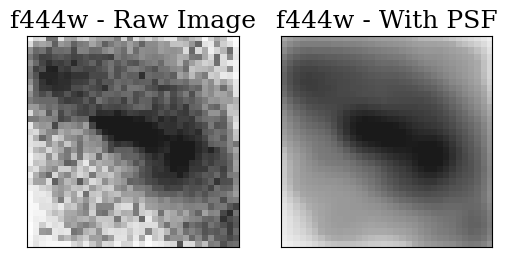

In [8]:
# ---------------------------
# -- PLOT BRIGHTEST IMAGES -- 
# ---------------------------
first_1000 = catalog[:1000]
# print(first_1000.colnames)
lum_FUV = np.log10(first_1000['lum_FUV'])
first_1000['M_FUV'] = 51.63 - 2.5 * lum_FUV

lum_mask = (first_1000['M_FUV']<-22.75) & (first_1000['M_FUV']>-23.25)
id_bright= first_1000[lum_mask]['id']
# print(first_1000['M_FUV'][id_bright])

for id in id_bright:
    print('ID =',id)
    plot_object(
        id,
        telescope='jwst',
        filter='f444w',
        catalog=catalog,
        redshift=7,
        add_noise=False)
    plt.show() 

15
[-23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125 -21.875 -21.625
 -21.375 -21.125 -20.875 -20.625 -20.375 -20.175]
Schechter Function Fit Results:
----------------------------------------
phi_star = 1.000e-03 +/- 9.503e-04
M_star   = -20.356 +/- 0.426
alpha    = -2.500 +/- 0.720
chi-squared/dof = 680.58/7 = 97.23


<>:123: SyntaxWarning: invalid escape sequence '\p'
<>:123: SyntaxWarning: invalid escape sequence '\p'
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_71914/2811846291.py:123: SyntaxWarning: invalid escape sequence '\p'
  textstr = f'$\phi^*$ = {popt[0]:.2e}\n$M^*$ = {popt[1]:.2f}\n$\\alpha$ = {popt[2]:.2f}'


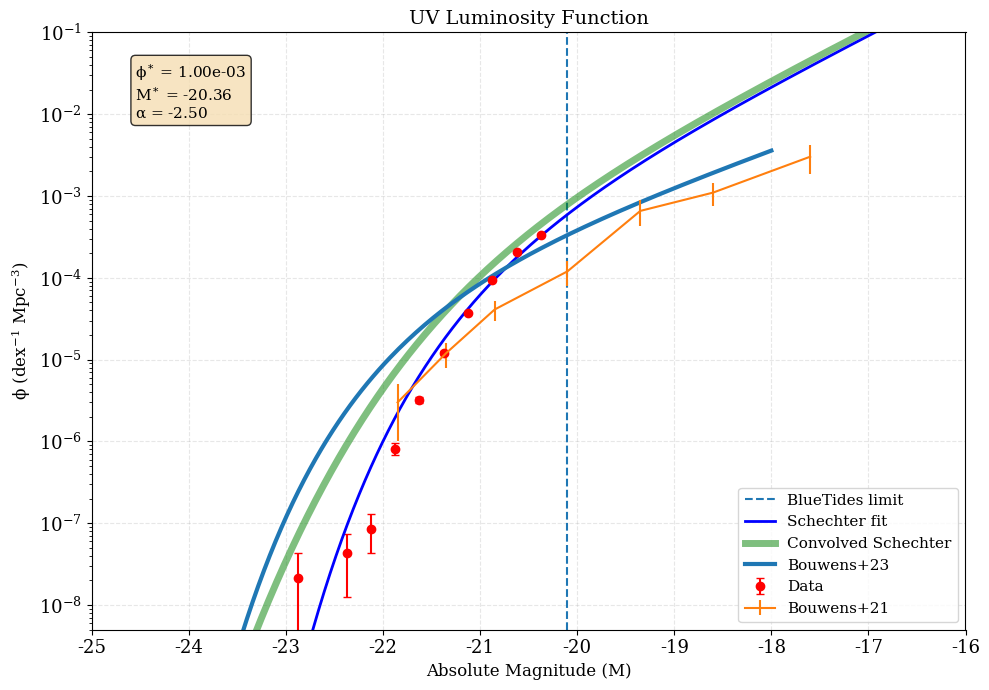

In [9]:
# Schechter function for UVLF (phi vs magnitude)
# https://en.wikipedia.org/wiki/Luminosity_function_(astronomy) for schecter formula in mags
def schechter(M, phi_star, M_star, alpha):
    """
    M: magnitude bins
    phi_star: normalization
    M_star: characteristic magnitude
    alpha: faint-end slope
    """
    x = 10**(0.4 * (M_star - M))
    return (0.4 * np.log(10) * phi_star * x**(alpha + 1) * np.exp(-x))

M_bins = uvlf_dict[7]['bin_centers'] # magnitude bin centers
phi = uvlf_dict[7]['phi_M']  # number densities
phi_err = uvlf_dict[7]['phi_err_M']  # errors

print(len(M_bins))
print(M_bins)

# M_bins = UVLF_SPLIT['M_median'] # magnitude bin centers
# phi = UVLF_SPLIT['phi']  # number densities
# phi_err = UVLF_SPLIT['phi_err']  # errors

mask = (np.isfinite(phi)) & (phi_err>0) & (phi>0) & (M_bins<-20.2)

M_bins = M_bins[mask]
phi = phi[mask]
phi_err = phi_err[mask]

# --------------------------------------
# Initial parameter guesses (Bouwens+21)
# --------------------------------------

# z = 6.8
phi_star_guess = 0.19e-3
M_star_guess = -21.15
alpha_guess = -2.06

# # z = 7.9
# phi_star_guess = 0.09e-3 
# M_star_guess = -20.93  
# alpha_guess = -2.23     

# z = 8.9
# phi_star_guess = 0.021e-3 
# M_star_guess = -21.25 
# alpha_guess = -2.33

p0 = [phi_star_guess, M_star_guess, alpha_guess]

bounds = (
    (1e-5, -22, -2.5),
    (1e-3, -20, 0)
)

# --------------------------------------
#               Fitting 
# --------------------------------------
popt, pcov = curve_fit(schechter, M_bins, phi, p0=p0, sigma=phi_err, bounds=bounds,
                        maxfev=5000)  
perr = np.sqrt(np.diag(pcov))

print("Schechter Function Fit Results:")
print("-" * 40)
print(f"phi_star = {popt[0]:.3e} +/- {perr[0]:.3e}")
print(f"M_star   = {popt[1]:.3f} +/- {perr[1]:.3f}")
print(f"alpha    = {popt[2]:.3f} +/- {perr[2]:.3f}")

# store best fit values
phi_star_fit, M_star_fit, alpha_fit = popt

# Calculate chi-squared
phi_fit_binned = schechter(M_bins, *popt)
chi2 = np.sum(((phi - phi_fit_binned) / phi_err)**2)
dof = len(M_bins) - len(popt)
print(f"chi-squared/dof = {chi2:.2f}/{dof} = {chi2/dof:.2f}")

# --------------------------------------
#              Plotting 
# --------------------------------------
plt.figure(figsize=(10, 7))

# show Bluetides magnitude limit
cutoff = -20.1
plt.axvline(cutoff, linestyle='--', label='BlueTides limit')

# Plot bluetides data (scatter)
plt.errorbar(M_bins, phi, yerr=phi_err, fmt='o', color='red', 
                capsize=3, markersize=6, label='Data')

# Plot fitting results (smooth)
M_smooth = np.arange(min(M_bins)-1, -16, 0.01)
phi_smooth = schechter(M_smooth, *popt)
plt.plot(M_smooth, phi_smooth, 'b-', linewidth=2, label='Schechter fit')

# Convovle phi with gaussian 1d kernel 
kernel = Gaussian1DKernel(stddev=0.4/0.01)
phi_conv = convolve(phi_smooth, kernel, boundary='extend')
plt.plot(M_smooth, phi_conv, c='green', linewidth=5, alpha=0.5, label='Convolved Schechter')

# Bouwens+23 (smooth)
M_bouwens = np.linspace(min(M_bins)-1, -18, 200)
bouwens_schecter = schechter(M_bouwens, phi_star_guess, M_star_guess, alpha_guess)
plt.plot(M_bouwens, bouwens_schecter, linewidth=3, label='Bouwens+23')

# Bouwens 2021 (scatter)
M_UV = [-21.85, -21.35, -20.85, -20.10, -19.35, -18.60, -17.60] 
phi = [0.000003, 0.000012, 0.000041, 0.000120, 0.000657, 0.001100, 0.003020] 
phi_err = [0.000002, 0.000004, 0.000011, 0.000040, 0.000233, 0.000340, 0.001140]
plt.errorbar(M_UV, phi, phi_err, label='Bouwens+21')

# Plot Configurations
plt.xlim(-25,-16)
plt.ylim(5e-9,1e-1)
plt.yscale('log')
plt.xlabel('Absolute Magnitude (M)', fontsize=12)
plt.ylabel(r'$\phi$ (dex$^{-1}$ Mpc$^{-3}$)', fontsize=12)
plt.title('UV Luminosity Function', fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11)

# Add parameter text box
textstr = f'$\phi^*$ = {popt[0]:.2e}\n$M^*$ = {popt[1]:.2f}\n$\\alpha$ = {popt[2]:.2f}'
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

positive alpha due to completeness limit <br>
see abs mag in Marshall+22 - does it evolve with z? <br>
if it doesn't evolve - right to left binning <br>
if it evolves: make last bin go from bright edge to completeness limit <br>
set floor - if last bin too small then don't include

#### Physical meaning of Gaussian convolution kernel:
typical uncertainty (1σ scatter) in a galaxy’s measured magnitude. <br>
above binsize = 0.01 (mag) <br>
mag uncertainty / binsize = number of bins spread over 

<br>

#### z=7 UVLF
might need DPL for z=7 (different slopes for bright end and faint end) <br>
hitting edge of bound for Mstar

<>:104: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\s'
<>:104: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\s'
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_71914/4008441904.py:104: SyntaxWarning: invalid escape sequence '\p'
  textstr = f'$\phi^*$ = {popt[0]:.2e}\n$M^*$ = {popt[1]:.2f}\n$\\alpha$ = {popt[2]:.2f}\n$\sigma$ = {popt[3]:.2f}'
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_71914/4008441904.py:104: SyntaxWarning: invalid escape sequence '\s'
  textstr = f'$\phi^*$ = {popt[0]:.2e}\n$M^*$ = {popt[1]:.2f}\n$\\alpha$ = {popt[2]:.2f}\n$\sigma$ = {popt[3]:.2f}'


Convolved Schechter Function Fit Results:
----------------------------------------
phi_star = 1.000e-03 +/- 1.191e-03
M_star   = -20.320 +/- 0.521
alpha    = -2.500 +/- 1.092
sigma    = 0.160 +/- 0.194
chi-squared/dof = 1046.87/7 = 149.55


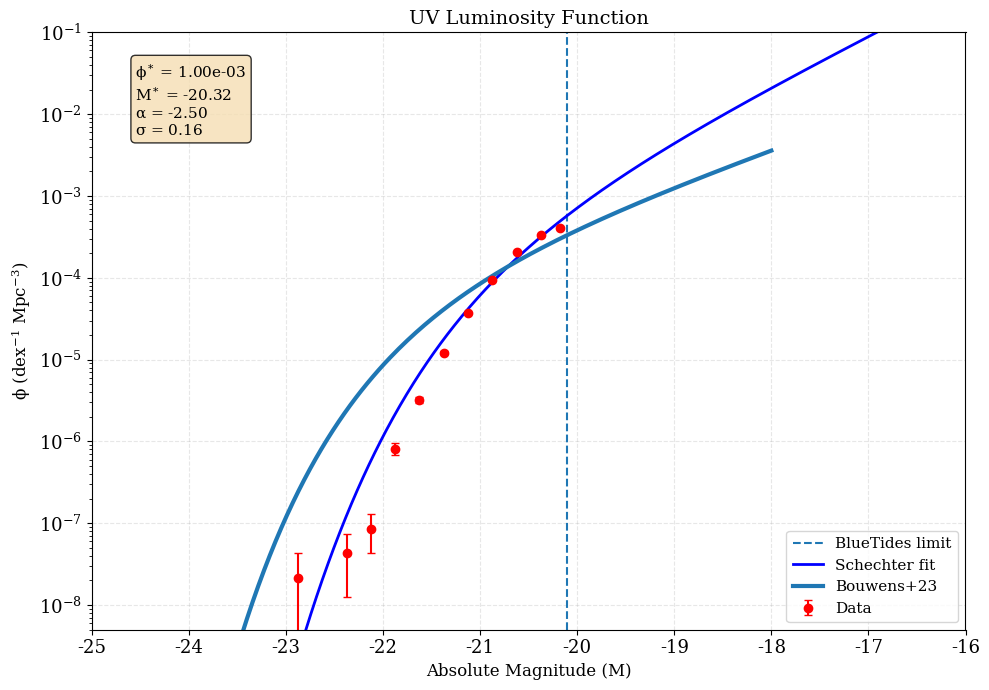

In [10]:
def convolved_schechter(M, phi_star, M_star, alpha, sigma):
    """
    Schechter function convolved with a Gaussian.

    M: magnitude bins
    phi_star, M_star, alpha: Schechter parameters
    sigma: Gaussian width (in magnitudes)
    """

    # Evaluate Schechter function
    phi = schechter(M, phi_star, M_star, alpha)

    dM = np.mean(np.diff(M))    # Grid spacing
    sigma_pix = sigma / dM      # convert to pixels

    kernel = Gaussian1DKernel(stddev=sigma_pix)
    
    phi_conv = convolve(phi, kernel, boundary='extend')

    return phi_conv

M_bins = uvlf_dict[7]['bin_centers'] # magnitude bin centers
phi = uvlf_dict[7]['phi_M']  # number densities
phi_err = uvlf_dict[7]['phi_err_M']  # errors


# M_bins = UVLF_SPLIT['M_median'] # magnitude bin centers
# phi = UVLF_SPLIT['phi']  # number densities
# phi_err = UVLF_SPLIT['phi_err']  # errors

mask = (np.isfinite(phi)) & (phi_err>0) & (phi>0)

M_bins = M_bins[mask]
phi = phi[mask]
phi_err = phi_err[mask]

# Initial parameter guesses

# z = 6.8
phi_star_guess = 0.19e-3
M_star_guess = -21.15
alpha_guess = -2.06
sigma_guess = 0.2

p0 = [phi_star_guess, M_star_guess, alpha_guess, sigma_guess]

bounds = (
    (1e-5, -22, -2.5, 0),
    (1e-3, -20, 0, 1)
)

# FITTING   
popt, pcov = curve_fit(convolved_schechter, M_bins, phi, p0=p0, sigma=phi_err, bounds=bounds,
                        maxfev=5000)  
perr = np.sqrt(np.diag(pcov))

print("Convolved Schechter Function Fit Results:")
print("-" * 40)
print(f"phi_star = {popt[0]:.3e} +/- {perr[0]:.3e}")
print(f"M_star   = {popt[1]:.3f} +/- {perr[1]:.3f}")
print(f"alpha    = {popt[2]:.3f} +/- {perr[2]:.3f}")
print(f"sigma    = {popt[3]:.3f} +/- {perr[3]:.3f}")

# Calculate chi-squared
phi_fit_binned = convolved_schechter(M_bins, *popt)
chi2 = np.sum(((phi - phi_fit_binned) / phi_err)**2)
dof = len(M_bins) - len(popt)
print(f"chi-squared/dof = {chi2:.2f}/{dof} = {chi2/dof:.2f}")

# --------------------------------------
#              Plotting 
# --------------------------------------
plt.figure(figsize=(10, 7))

# show Bluetides magnitude limit
cutoff = -20.1
plt.axvline(cutoff, linestyle='--', label='BlueTides limit')

# Plot bluetides data (scatter)
plt.errorbar(M_bins, phi, yerr=phi_err, fmt='o', color='red', 
                capsize=3, markersize=6, label='Data')

# Plot fitting results (smooth)
M_smooth = np.arange(min(M_bins)-1, -16, 0.01)
phi_smooth = convolved_schechter(M_smooth, *popt)
plt.plot(M_smooth, phi_smooth, 'b-', linewidth=2, label='Schechter fit')

# Bouwens+23 (smooth, regular Schechter)
M_bouwens = np.linspace(min(M_bins)-1, -18, 200)
bouwens_schecter = schechter(M_bouwens, phi_star_guess, M_star_guess, alpha_guess)
plt.plot(M_bouwens, bouwens_schecter, linewidth=3, label='Bouwens+23')


plt.xlim(-25,-16)
plt.ylim(5e-9,1e-1)
plt.yscale('log')
plt.xlabel('Absolute Magnitude (M)', fontsize=12)
plt.ylabel(r'$\phi$ (dex$^{-1}$ Mpc$^{-3}$)', fontsize=12)
plt.title('UV Luminosity Function', fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11)

# Add parameter text box
textstr = f'$\phi^*$ = {popt[0]:.2e}\n$M^*$ = {popt[1]:.2f}\n$\\alpha$ = {popt[2]:.2f}\n$\sigma$ = {popt[3]:.2f}'
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

sigma = 0.342 +/- 0.145
chi2/dof = 783.51/199 = 3.94


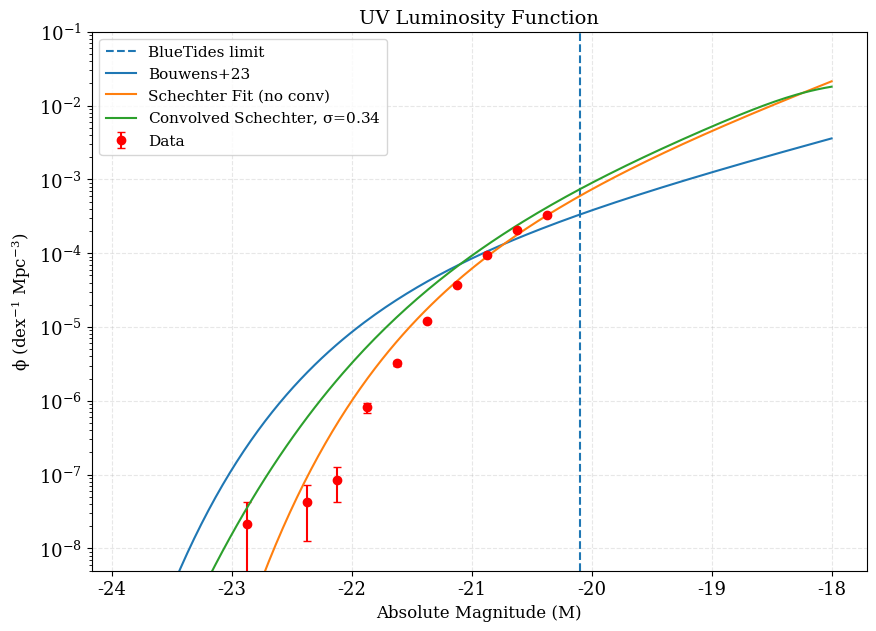

In [11]:
# fitting only sigma

M_bins = uvlf_dict[7]['bin_centers'] # magnitude bin centers
phi = uvlf_dict[7]['phi_M']  # number densities
phi_err = uvlf_dict[7]['phi_err_M']  # errors


# M_bins = UVLF_SPLIT['M_median'] # magnitude bin centers
# phi = UVLF_SPLIT['phi']  # number densities
# phi_err = UVLF_SPLIT['phi_err']  # errors

mask = (np.isfinite(phi)) & (phi_err>0) & (phi>0) & (M_bins<-20.2)

M_bins = M_bins[mask]
phi = phi[mask]
phi_err = phi_err[mask]

# Target UVLF
M_bouwens = np.linspace(min(M_bins)-1, -18, 200)
bouwens_schecter = schechter(M_bouwens, phi_star_guess, M_star_guess, alpha_guess)

def model_sigma_only(M, sigma):
    """
    Finds the best sigma for a Gaussian convolution kernel 
    such that my best-fit matches Bouwens+23

    phi_star_fit, M_star_fit, alpha_fit all taken from my
    fitting of a Schecter function to the data
    """
    return convolved_schechter(
        M, 
        phi_star_fit, M_star_fit, alpha_fit,
        sigma
    )

sigma_guess = 0.2

popt, pcov = curve_fit(
    model_sigma_only,   # model for my Schechter fit
    M_bouwens,          # uniform magnitude grid
    bouwens_schecter,   # target UVLF
    p0=[sigma_guess],
    bounds=(0, 1)
)

# Print best fit sigma
sigma_best = popt[0]
sigma_err = np.sqrt(np.diag(pcov))[0]
print(f"sigma = {sigma_best:.3f} +/- {sigma_err:.3f}")

# Goodness of fit
phi_conv = model_sigma_only(M_bouwens, sigma_best)
chi2 = np.sum(((bouwens_schecter - phi_conv) / bouwens_schecter)**2)
dof = len(M_bouwens) - 1
print(f"chi2/dof = {chi2:.2f}/{dof} = {chi2/dof:.2f}")

# --------------------------------------
#              Plotting 
# --------------------------------------
plt.figure(figsize=(10, 7))

# show Bluetides magnitude limit
cutoff = -20.1
plt.axvline(cutoff, linestyle='--', label='BlueTides limit')

# Plot bluetides data (scatter)
plt.errorbar(M_bins, phi, yerr=phi_err, fmt='o', color='red', 
                capsize=3, markersize=6, label='Data')
 
plt.plot(M_bouwens, bouwens_schecter, label='Bouwens+23')

phi_og_fit = schechter(
    M_bouwens, 
    phi_star=phi_star_fit,
    M_star=M_star_fit,
    alpha=alpha_fit
    )
plt.plot(M_bouwens, phi_og_fit, label='Schechter Fit (no conv)')

plt.plot(M_bouwens, phi_conv, label=rf'Convolved Schechter, $\sigma$={sigma_best:.2f}')

# Plot configurations
plt.ylim(5e-9,1e-1)
plt.yscale('log')
plt.xlabel('Absolute Magnitude (M)', fontsize=12)
plt.ylabel(r'$\phi$ (dex$^{-1}$ Mpc$^{-3}$)', fontsize=12)
plt.title('UV Luminosity Function', fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11)

compare pre-JWST and post-JWST from Bouwens+21, +23 <br>
check values are consistent with my data and Marshall <br>
compare alpha values from all fits <br>
is bluetides low alpha correct <br>

Schechter Function Fit Results:
----------------------------------------
alpha    = -1.485 +/- 0.256
beta     = -6.447 +/- 0.235
M_star   = -20.690 +/- 0.058
phi_star = 3.526e-04 +/- 5.511e-05
chi-squared/dof = 42.51/7 = 6.07


<>:87: SyntaxWarning: invalid escape sequence '\p'
<>:87: SyntaxWarning: invalid escape sequence '\p'
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_71914/1475329510.py:87: SyntaxWarning: invalid escape sequence '\p'
  textstr = f'$\phi^*$ = {popt[3]:.2e}\n$M^*$ = {popt[2]:.2f}\n$\\alpha$ = {popt[0]:.2f}\n$\\beta$ = {popt[1]:.2f}'


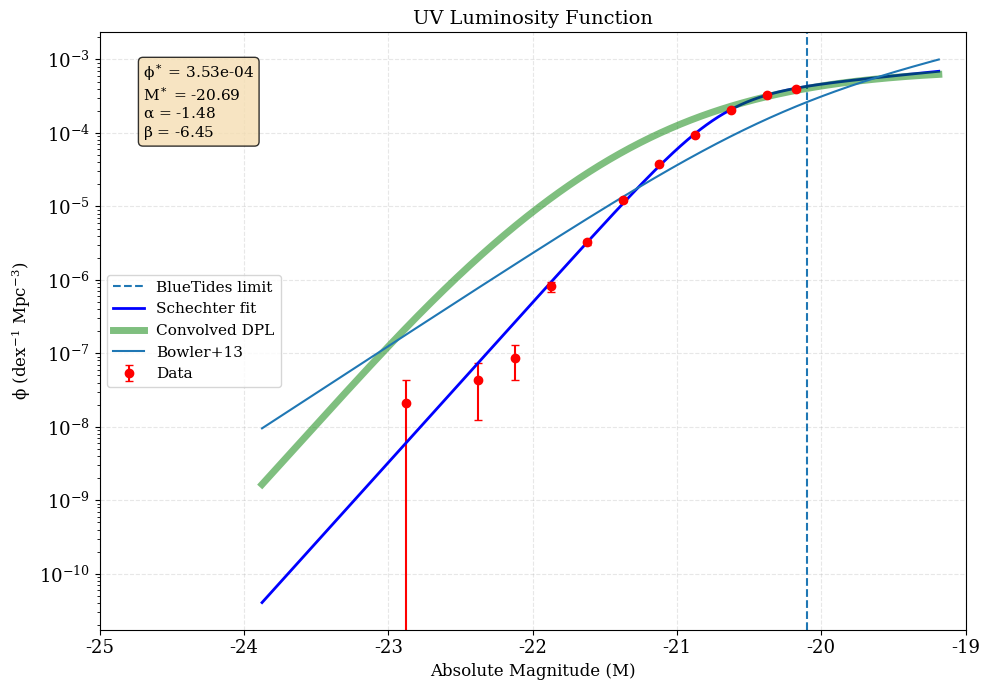

In [12]:
def double_power_law(M, alpha, beta, M_star, phi_star):
    """
    Double power-law luminosity function in magnitude space
    """
    term_faint = 10**(0.4 * (alpha + 1) * (M - M_star))
    term_bright = 10**(0.4 * (beta + 1) * (M - M_star))

    return phi_star / (term_faint + term_bright)

M_bins = uvlf_dict[7]['bin_centers'] # magnitude bin centers
phi = uvlf_dict[7]['phi_M']  # number densities
phi_err = uvlf_dict[7]['phi_err_M']  # errors

# M_bins = UVLF_SPLIT['M_median'] # magnitude bin centers
# phi = UVLF_SPLIT['phi']  # number densities
# phi_err = UVLF_SPLIT['phi_err']  # errors

mask = (np.isfinite(phi)) & (phi_err>0) & (phi>0)

M_bins = M_bins[mask]
phi = phi[mask]
phi_err = phi_err[mask]

# Numbers from Bowler 2013
phi_star_guess = 3.6e-4
M_star_guess = -20.3
alpha_guess = -2.1
beta_guess = -4.2

p0 = [alpha_guess, beta_guess, M_star_guess, phi_star_guess]

popt, pcov = curve_fit(double_power_law, M_bins, phi, p0=p0, sigma=phi_err, 
                        maxfev=5000)  
perr = np.sqrt(np.diag(pcov))

print("Schechter Function Fit Results:")
print("-" * 40)
print(f"alpha    = {popt[0]:.3f} +/- {perr[0]:.3f}")
print(f"beta     = {popt[1]:.3f} +/- {perr[1]:.3f}")
print(f"M_star   = {popt[2]:.3f} +/- {perr[2]:.3f}")
print(f"phi_star = {popt[3]:.3e} +/- {perr[3]:.3e}")

# Calculate chi-squared
phi_fit_binned = double_power_law(M_bins, *popt)
chi2 = np.sum(((phi - phi_fit_binned) / phi_err)**2)
dof = len(M_bins) - len(popt)
print(f"chi-squared/dof = {chi2:.2f}/{dof} = {chi2/dof:.2f}")

# --------------------------------------
#              Plotting 
# --------------------------------------
plt.figure(figsize=(10, 7))

# show Bluetides magnitude limit
cutoff = -20.1
plt.axvline(cutoff, linestyle='--', label='BlueTides limit')

# Plot BlueTides data (scatter)
plt.errorbar(M_bins, phi, yerr=phi_err, fmt='o', color='red', 
                capsize=3, markersize=6, label='Data')

# Plot fitting results (smooth)
M_smooth = np.arange(min(M_bins)-1, max(M_bins)+1, 0.01)
phi_smooth = double_power_law(M_smooth, *popt)
plt.plot(M_smooth, phi_smooth, 'b-', linewidth=2, label='Schechter fit')

# Convovle phi with gaussian 1d kernel 
kernel = Gaussian1DKernel(stddev=0.55/0.01)
phi_conv = convolve(phi_smooth, kernel, boundary='extend')
plt.plot(M_smooth, phi_conv, c='green', linewidth=5, alpha=0.5, label='Convolved DPL')

# Bowler 2013 (smooth)
bowler_dpl = double_power_law(M_smooth, alpha_guess, beta_guess, M_star_guess, phi_star_guess)
plt.plot(M_smooth, bowler_dpl, label='Bowler+13')

# Plot configurations
plt.xlim(-25,-19)
# plt.ylim(1e-7,1e-1)
plt.yscale('log')
plt.xlabel('Absolute Magnitude (M)', fontsize=12)
plt.ylabel(r'$\phi$ (dex$^{-1}$ Mpc$^{-3}$)', fontsize=12)
plt.title('UV Luminosity Function', fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11)

# Add parameter text box
textstr = f'$\phi^*$ = {popt[3]:.2e}\n$M^*$ = {popt[2]:.2f}\n$\\alpha$ = {popt[0]:.2f}\n$\\beta$ = {popt[1]:.2f}'
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

You must install the tqdm library to use progress indicators with emcee


Best-fit parameters:
alpha = -1.0171015650942434
M* = -19.850911857557307
log10(phi*) = -3.9550394192828753


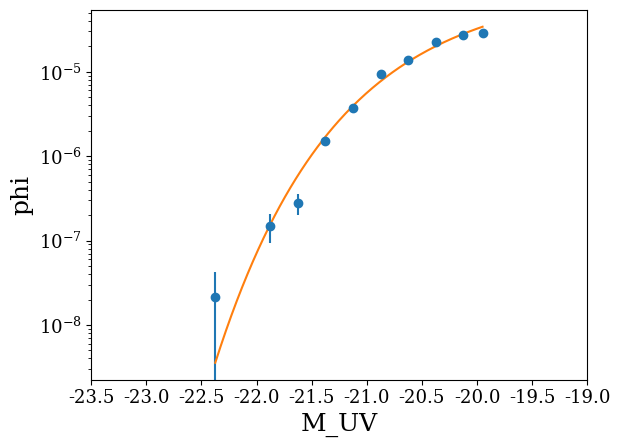

In [13]:
M_bins = uvlf_dict[9]['bin_centers'] # magnitude bin centers
phi = uvlf_dict[9]['phi_M']  # number densities
phi_err = uvlf_dict[9]['phi_err_M']  # errors

# M_bins = UVLF_SPLIT['M_median'] # magnitude bin centers
# phi = UVLF_SPLIT['phi']  # number densities
# phi_err = UVLF_SPLIT['phi_err']  # errors


mask = (np.isfinite(phi)) & (phi_err>0) & (phi>0)

M_bins = M_bins[mask]
phi = phi[mask]
phi_err = phi_err[mask]

# --- FUNCTIONS ---
def schechter(M, alpha, M_star, log10_phi_star):
    """
    M: magnitude bins
    phi_star: normalization
    M_star: characteristic magnitude
    alpha: faint-end slope
    """
    phi_star = 10**log10_phi_star
    x = 10**(0.4 * (M_star - M))
    return (0.4 * np.log(10) * phi_star * x**(alpha + 1) * np.exp(-x))


# Log Prior
def log_prior(theta):
    alpha, M_star, log10_phi_star = theta

    if -3.5 < alpha < -1.0 and \
       -23 < M_star < -18 and \
       -8 < log10_phi_star < -1:
        return 0.0  # flat prior
    return -np.inf


# Log Likelihood (Gaussian errors on phi)
def log_likelihood(theta, M, phi_obs, phi_err):
    alpha, M_star, log10_phi_star = theta
    model = schechter(M, alpha, M_star, log10_phi_star)

    return -0.5 * np.sum(
        (phi_obs - model)**2 / phi_err**2 +
        np.log(2 * np.pi * phi_err**2)
    )


# Log Posterior
def log_probability(theta, M, phi_obs, phi_err):
    lp = log_prior(theta)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, M, phi_obs, phi_err)


# Initialize Sampler
ndim = 3
nwalkers = 100

# Initial guess (adjust if needed)
initial = np.array([-2.0, -20.5, -4.5])
pos = initial + 1e-3 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability,
    args=(M_bins, phi, phi_err)
)

# Run MCMC
nsteps = 5000
sampler.run_mcmc(pos, nsteps, progress=True)

# Remove burn-in & flatten chain
samples = sampler.get_chain(discard=1000, flat=True)

# Posterior summaries
alpha_mcmc, Mstar_mcmc, logphi_mcmc = np.percentile(samples, 50, axis=0)

print("Best-fit parameters:")
print("alpha =", alpha_mcmc)
print("M* =", Mstar_mcmc)
print("log10(phi*) =", logphi_mcmc)

M_fit = np.linspace(min(M_bins), max(M_bins), 200)
phi_fit = schechter(M_fit, alpha_mcmc, Mstar_mcmc, logphi_mcmc)

plt.errorbar(M_bins, phi, yerr=phi_err, fmt='o')
plt.plot(M_fit, phi_fit)
plt.xlim(-23.5,-19)
plt.yscale('log')
plt.xlabel("M_UV")
plt.ylabel("phi")
# plt.gca().invert_xaxis()
plt.show()

You must install the tqdm library to use progress indicators with emcee


Best-fit parameters:
alpha = -1.0318067185750457
beta = -5.917668274188406
M* = -21.315537315710568
log10(phi*) = -3.393980058470619


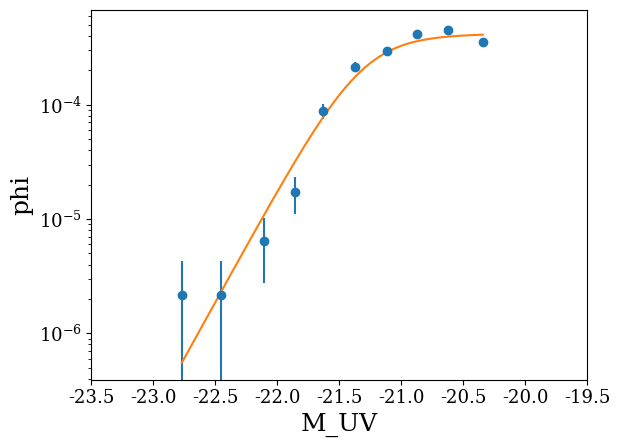

In [14]:
M_bins = uvlf_dict[7]['bin_centers'] # magnitude bin centers
phi = uvlf_dict[7]['phi_M']  # number densities
phi_err = uvlf_dict[7]['phi_err_M']  # errors

M_bins = UVLF_SPLIT['M_median'] # magnitude bin centers
phi = UVLF_SPLIT['phi']  # number densities
phi_err = UVLF_SPLIT['phi_err']  # errors

mask = (np.isfinite(phi)) & (phi_err>0) & (phi>0) & (M_bins<-19)

M_bins = M_bins[mask]
phi = phi[mask]
phi_err = phi_err[mask]


def double_power_law(M, alpha, beta, M_star, log10_phi_star):
    """
    Double power-law luminosity function in magnitude space
    """
    phi_star = 10**log10_phi_star

    term_faint = 10**(0.4 * (alpha + 1) * (M - M_star))
    term_bright = 10**(0.4 * (beta + 1) * (M - M_star))

    return phi_star / (term_faint + term_bright)

def log_prior(theta):
    alpha, beta, M_star, log10_phi_star = theta

    if -3.5 < alpha < -1.0 and \
       -6.0 < beta < -1.0 and \
       -23 < M_star < -18 and \
       -8 < log10_phi_star < -1:
        return 0.0

    return -np.inf


# Log Likelihood (Gaussian errors on phi)
def log_likelihood(theta, M, phi_obs, phi_err):
    alpha, beta, M_star, log10_phi_star = theta

    model = double_power_law(M, alpha, beta, M_star, log10_phi_star)

    return -0.5 * np.sum(
        (phi_obs - model)**2 / phi_err**2 +
        np.log(2 * np.pi * phi_err**2)
    )


# Log Posterior
def log_probability(theta, M, phi_obs, phi_err):
    lp = log_prior(theta)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, M, phi_obs, phi_err)


# Initialize Sampler
ndim = 4
nwalkers = 64

# Initial guess (adjust if needed)
initial = np.array([-2.0, -4.0, -20.5, -3.0])
pos = initial + 1e-3 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability,
    args=(M_bins, phi, phi_err)
)

# Run MCMC
nsteps = 5000
sampler.run_mcmc(pos, nsteps, progress=True)

# Remove burn-in & flatten chain
samples = sampler.get_chain(discard=1000, flat=True)

# POSTERIOR
alpha_mcmc, beta_mcmc, Mstar_mcmc, logphi_mcmc = np.percentile(samples, 50, axis=0)

print("Best-fit parameters:")
print("alpha =", alpha_mcmc)
print("beta =", beta_mcmc)
print("M* =", Mstar_mcmc)
print("log10(phi*) =", logphi_mcmc)

M_fit = np.linspace(min(M_bins), max(M_bins), 200)
phi_fit = double_power_law(M_fit, alpha_mcmc, beta_mcmc, Mstar_mcmc, logphi_mcmc)

plt.errorbar(M_bins, phi, yerr=phi_err, fmt='o')
plt.plot(M_fit, phi_fit)

plt.xlim(-23.5, -19.5)
plt.yscale('log')
plt.xlabel("M_UV")
plt.ylabel("phi")

plt.show()

In [15]:
print(np.max(M_bins))

-20.344394358490142


You must install the tqdm library to use progress indicators with emcee


Best-fit parameters:
alpha = -1.024152489520173
M* = -20.57363792613814
log10(phi*) = -2.9508886382672026
log_sigma = -3.723450754695504


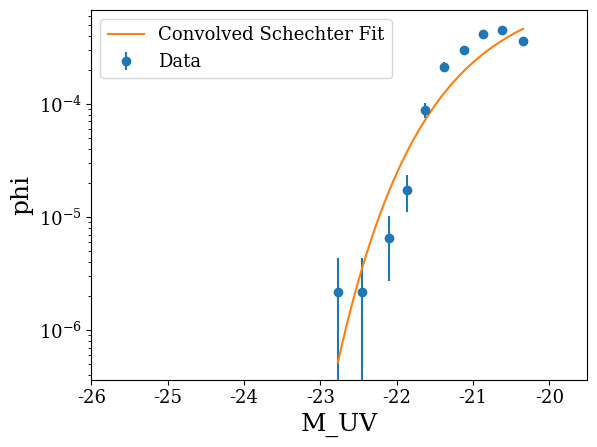

In [16]:
# SCHECTER FUNCTION + CONVOLUTION

# -----------------------------
# UVLF data
# -----------------------------

# RAW BLUETIDES DATA
M_bins = uvlf_dict[7]['bin_centers']  # magnitude bin centers
phi = uvlf_dict[7]['phi_M']           # number densities
phi_err = uvlf_dict[7]['phi_err_M']   # errors

# EXPERIMENT DATA
M_bins = UVLF_SPLIT['M_median']  # magnitude bin centers
phi = UVLF_SPLIT['phi']          # number densities
phi_err = UVLF_SPLIT['phi_err']  # errors

# Only use finite, positive data
mask = (np.isfinite(phi)) & (phi_err>0) & (phi>0) & (M_bins<-19)
M_bins = M_bins[mask]
phi = phi[mask]
phi_err = phi_err[mask]

# -----------------------------
# Schechter function
# -----------------------------
def schechter(M, alpha, M_star, log10_phi_star):
    phi_star = 10**log10_phi_star
    term1 = 0.4 * np.log(10) * phi_star
    term2 = 10**(0.4 * (M_star - M) * (alpha + 1))
    term3 = np.exp(-10**(0.4 * (M_star - M)))
    return term1 * term2 * term3

# -----------------------------
# Convolved Schechter using astropy
# -----------------------------
def convolved_schecter(M_eval, alpha, M_star, log10_phi_star, log_sigma):
    """
    Convolve Schechter function with a Gaussian using astropy.convolution
    """
    # Convert log10_phi_star to phi_star
    phi_star = 10**log10_phi_star

    # Evaluate Schechter on the data points
    phi = schechter(M_eval, alpha, M_star, log10_phi_star)

    # Create a fine grid for convolution
    M_fine = np.linspace(min(M_bins)-2, max(M_bins)+2, 2000)
    dM = M_fine[1] - M_fine[0]
    phi_fine = schechter(M_fine, alpha, M_star, log10_phi_star)

    # Gaussian kernel in pixels
    sigma_pix = np.exp(log_sigma) / dM
    kernel = Gaussian1DKernel(stddev=sigma_pix)

    # Convolve using astropy
    phi_conv_fine = convolve(phi_fine, kernel, boundary='extend')

    # Interpolate back to M_eval
    interp = interp1d(M_fine, phi_conv_fine, bounds_error=False, fill_value=0.0)
    return interp(M_eval)

# -----------------------------
# Log prior
# -----------------------------
def log_prior(theta):
    alpha, M_star, log10_phi_star, log_sigma = theta
    if -3.5 < alpha < -1.0 and \
       -23 < M_star < -18 and \
       -8 < log10_phi_star < -1 and \
       -5 < log_sigma < 1:
        return 0.0
    return -np.inf

# -----------------------------
# Log likelihood
# -----------------------------
def log_likelihood(theta, M, phi_obs, phi_err):
    model = convolved_schecter(M, *theta)
    return -0.5 * np.sum((phi_obs - model)**2 / phi_err**2 +
                         np.log(2 * np.pi * phi_err**2))

# -----------------------------
# Log posterior
# -----------------------------
def log_probability(theta, M, phi_obs, phi_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, M, phi_obs, phi_err)

# -----------------------------
# Run emcee
# -----------------------------
ndim = 4
nwalkers = 40
initial = np.array([-2.0, -20.5, -3.0, np.log(0.2)])
pos = initial + 1e-3 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability,
    args=(M_bins, phi, phi_err)
)

sampler.run_mcmc(pos, 6000, progress=True)

samples = sampler.get_chain(discard=1500, flat=True)

# -----------------------------
# Extract median parameters
# -----------------------------
alpha_mcmc, Mstar_mcmc, logphi_mcmc, logsigma_mcmc = np.percentile(samples, 50, axis=0)

print("Best-fit parameters:")
print("alpha =", alpha_mcmc)
print("M* =", Mstar_mcmc)
print("log10(phi*) =", logphi_mcmc)
print("log_sigma =", logsigma_mcmc)

# -----------------------------
# Plot the convolved fit
# -----------------------------
M_fit = np.linspace(min(M_bins), max(M_bins), 200)
phi_fit = convolved_schecter(M_fit, alpha_mcmc, Mstar_mcmc, logphi_mcmc, logsigma_mcmc)

plt.errorbar(M_bins, phi, yerr=phi_err, fmt='o', label='Data')
plt.plot(M_fit, phi_fit, label='Convolved Schechter Fit')
plt.xlim(-26, -19.5)
plt.yscale('log')
plt.xlabel("M_UV")
plt.ylabel("phi")
plt.legend()
plt.show()

## Sampling and Reproducing UVLF

#### Step 1:
Write a function that samples magnitudes from a given UVLF
#### Step 2:
generate many UVLFs from Bouwens+23 values + errors (assume Gaussian) 
#### Step 3:
Reproduce Bouwens from M_UV sample

#### Russian roulette step:
function that takes random draws to split galaxies and reproduce Bluetides <br>
probability of being split in 2 defined by softening function<br>

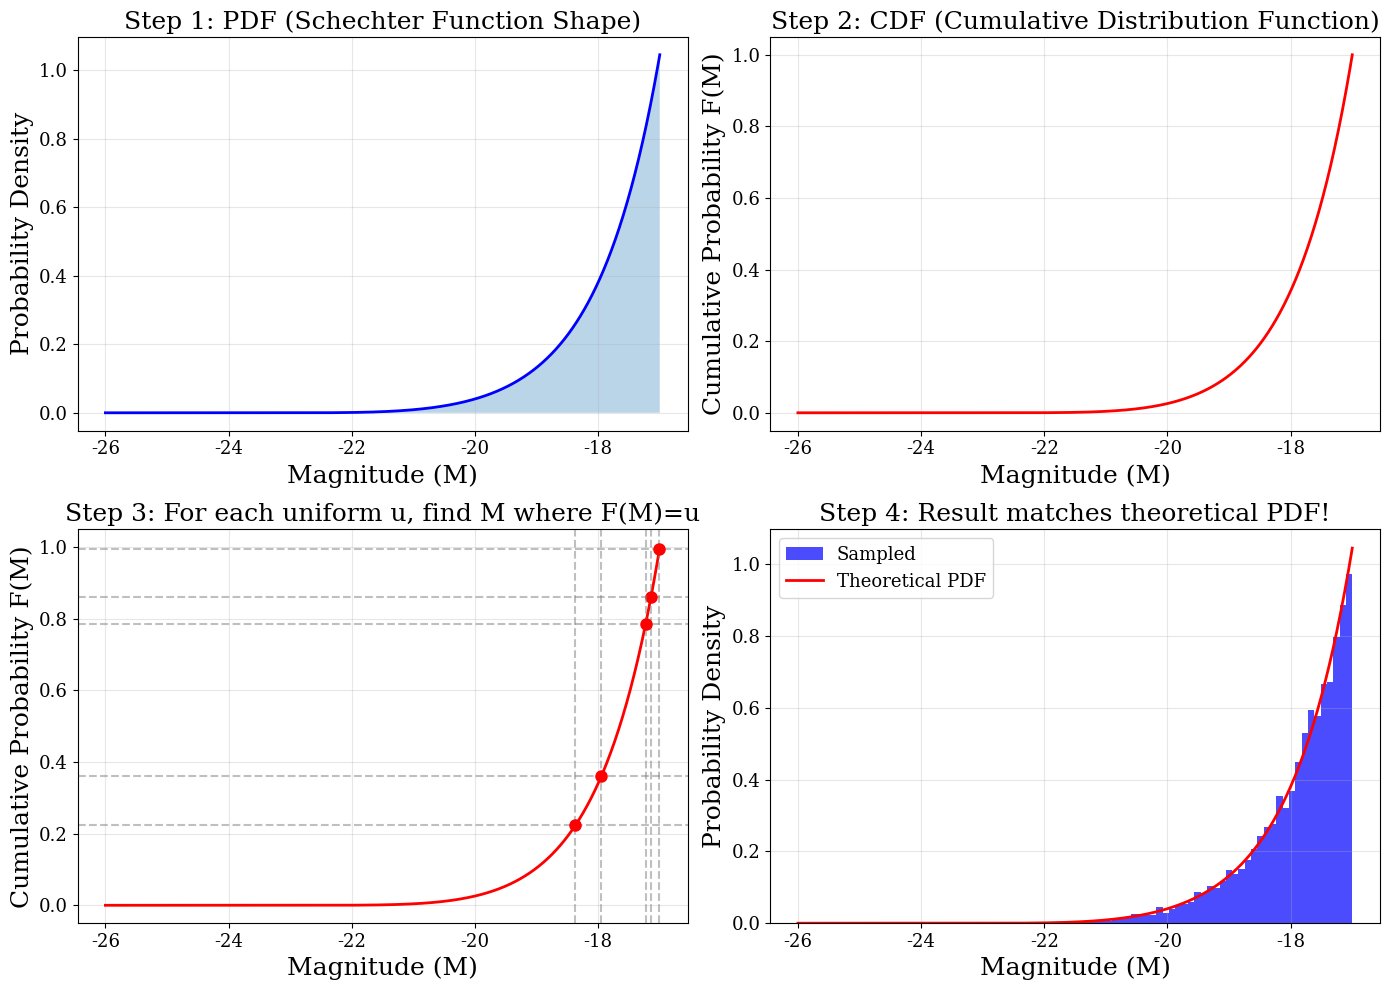

Generated 10000 samples
Sample range: [-22.13, -17.00]


In [ ]:
# ----------------------------------------
# ------ INVERSE TRANSFORM SAMPLING ------
# (this cell just walks through the steps)
# ----------------------------------------
from scipy.integrate import cumulative_trapezoid

# Parameters: 
# don't need Phi* for shape (proof below)
M_star = -21.15
alpha = -2.06
M_min, M_max = -26, -17

# Step 1: Compute the PDF (phi) and CDF 
# for a Schechter function with given parameters
M_grid = np.linspace(M_min, M_max, 1000)
x = 10 ** (-0.4 * (M_grid - M_star))
phi = x ** (alpha + 1) * np.exp(-x)     # Unnormalized PDF
phi = phi / np.trapezoid(phi, M_grid)   # Normalized PDF

# Compute CDF by integration
cdf = cumulative_trapezoid(phi, M_grid, initial=0)

# Step 2: Generate uniform random numbers between 0 and 1
n_samples = 10000
u = np.random.uniform(0, 1, n_samples)

# Step 3: Find values of M such that CDF(M) = u (inverse transform)
M_samples = np.interp(u, cdf, M_grid)

# Visualize the process
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: The PDF (Schechter function shape)
ax1 = axes[0, 0]
ax1.plot(M_grid, phi, 'b-', linewidth=2)
ax1.fill_between(M_grid, phi, alpha=0.3)
ax1.set_xlabel('Magnitude (M)')
ax1.set_ylabel('Probability Density')
ax1.set_title('Step 1: PDF (Schechter Function Shape)')
ax1.grid(True, alpha=0.3)

# Plot 2: The CDF
ax2 = axes[0, 1]
ax2.plot(M_grid, cdf, 'r-', linewidth=2)
ax2.set_xlabel('Magnitude (M)')
ax2.set_ylabel('Cumulative Probability F(M)')
ax2.set_title('Step 2: CDF (Cumulative Distribution Function)')
ax2.grid(True, alpha=0.3)

# Plot 3: How inverse transform works (pick a random u, find M)
ax3 = axes[1, 0]
ax3.plot(M_grid, cdf, 'r-', linewidth=2)

# Show 5 random examples
for i in range(5):
    u_val = np.random.uniform(0, 1)
    M_val = np.interp(u_val, cdf, M_grid)
    ax3.axhline(y=u_val, color='gray', linestyle='--', alpha=0.5)
    ax3.axvline(x=M_val, color='gray', linestyle='--', alpha=0.5)
    ax3.plot(M_val, u_val, 'ro', markersize=8)

ax3.set_xlabel('Magnitude (M)')
ax3.set_ylabel('Cumulative Probability F(M)')
ax3.set_title('Step 3: For each uniform u, find M where F(M)=u')
ax3.grid(True, alpha=0.3)

# Plot 4: Resulting sampled magnitudes
ax4 = axes[1, 1]
ax4.hist(M_samples, bins=50, density=True, alpha=0.7, label='Sampled', color='blue')
ax4.plot(M_grid, phi, 'r-', linewidth=2, label='Theoretical PDF')
ax4.set_xlabel('Magnitude (M)')
ax4.set_ylabel('Probability Density')
ax4.set_title('Step 4: Result matches theoretical PDF!')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Generated {n_samples} samples")
print(f"Sample range: [{M_samples.min():.2f}, {M_samples.max():.2f}]")

In [ ]:
# RANDOMLY GENERATING NEW SCHECHTER FUNCTION PARAMETERS

# z = 6.8 params (Bouwens+21)
phi_star_guess = 0.19e-3
M_star_guess = -21.15
alpha_guess = -2.06

phi_star_err = 0.08e-3
M_star_err = 0.13
alpha_err = 0.11

# Magnitude bins to sample at
magnitude_bins = np.arange(-26.25, -17.25, 0.5)
n_bins = len(magnitude_bins) - 1
bin_centers = (magnitude_bins[:-1] + magnitude_bins[1:]) / 2

# Number of Monte Carlo samples
n_samples = 10000

# Sample parameters from Gaussian distributions
np.random.seed(42)  # For reproducibility
M_star_samples = np.random.normal(M_star_guess, M_star_err, n_samples)
phi_star_samples = np.random.normal(phi_star_guess, phi_star_err, n_samples)
alpha_samples = np.random.normal(alpha_guess, alpha_err, n_samples)

# Ensure phi_star is positive, alpha is negative (physical constraint)
phi_star_samples = np.maximum(phi_star_samples, 0)
alpha_samples = np.minimum(alpha_samples, 0)

print(f"Generated {n_samples} parameter samples")
print(f"M_star: {M_star_samples.mean():.2f} ± {M_star_samples.std():.2f}")
print(f"Phi_star: {phi_star_samples.mean():.3e} ± {phi_star_samples.std():.3e}")
print(f"alpha: {alpha_samples.mean():.2f} ± {alpha_samples.std():.2f}")

Generated 10000 parameter samples
M_star: -21.15 ± 0.13
Phi_star: 1.914e-04 ± 7.931e-05
alpha: -2.06 ± 0.11


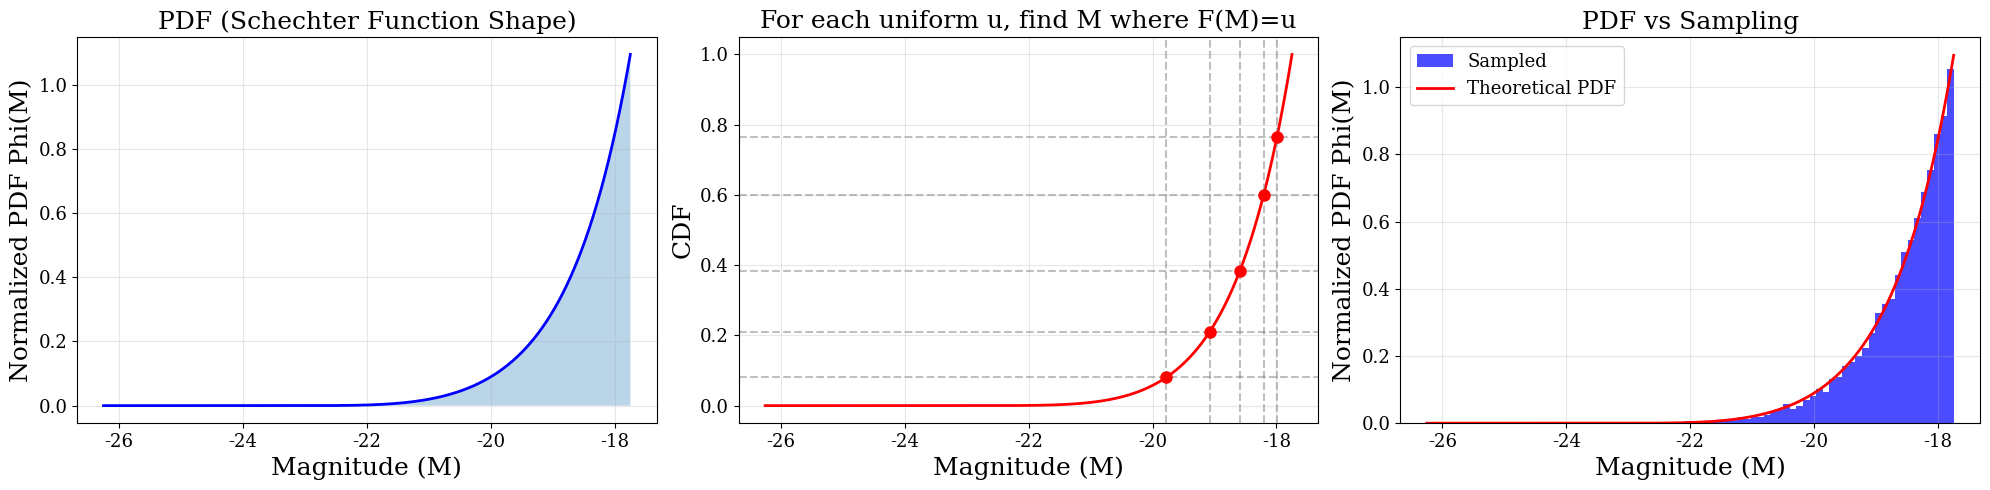

Generated 10000 samples
Sample range: [-23.03, -17.75]


In [ ]:
# SAMPLE MAGNITUDES FROM SCHECHTER FUNCTION
# Using inverse transform sampling (see example above)

def cumulative(x):
    x = x[~np.isnan(x)]
    N = len(x)
    return np.sort(x), np.array(np.linspace(0,N,N) )/float(N)

def sample_from_schechter(n_samples, M_star, alpha, M_min, M_max, plot_results=False):
    """
    Generate samples using inverse transform sampling.
    Uses the theoretical CDF of the Schechter function
    """
    # Create fine magnitude grid
    M_grid = np.linspace(M_min, M_max, 10000)

    # Compute the Schechter function (unnormalized)
    x = 10 ** (-0.4 * (M_grid - M_star))
    phi_grid = x ** (alpha + 1) * np.exp(-x)
    phi_grid = phi_grid / np.trapezoid(phi_grid, M_grid)
    
    # Numerical integration to get CDF
    # cumulative_trapezoid keeps running total of trapezoid areas
    cdf = cumulative_trapezoid(phi_grid, M_grid, initial=0)
        
    # Sample uniformly and interpolate
    u = np.random.uniform(0, 1, n_samples)
    M_samples = np.interp(u, cdf, M_grid)

    if plot_results == True:
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))

        # Plot 1: The PDF (Schechter function shape)
        ax1 = axes[0]
        ax1.plot(M_grid, phi_grid, 'b-', linewidth=2)
        ax1.fill_between(M_grid, phi_grid, alpha=0.3)
        ax1.set_xlabel('Magnitude (M)')
        ax1.set_ylabel('Normalized PDF Phi(M)')
        ax1.set_title('PDF (Schechter Function Shape)')
        ax1.grid(True, alpha=0.3)

        # Plot 2: How inverse transform works (pick a random u, find M)
        ax2 = axes[1]
        ax2.plot(M_grid, cdf, 'r-', linewidth=2)

        # Show 5 random examples
        for i in range(5):
            u_val = np.random.uniform(0, 1)
            M_val = np.interp(u_val, cdf, M_grid)
            ax2.axhline(y=u_val, color='gray', linestyle='--', alpha=0.5)
            ax2.axvline(x=M_val, color='gray', linestyle='--', alpha=0.5)
            ax2.plot(M_val, u_val, 'ro', markersize=8)

        ax2.set_xlabel('Magnitude (M)')
        ax2.set_ylabel('CDF')
        ax2.set_title('For each uniform u, find M where F(M)=u')
        ax2.grid(True, alpha=0.3)

        # Plot 3: Resulting sampled magnitudes
        ax3 = axes[2]
        ax3.hist(M_samples, bins=50, density=True, alpha=0.7, label='Sampled', color='blue')
        ax3.plot(M_grid, phi_grid, 'r-', linewidth=2, label='Theoretical PDF')
        ax3.set_xlabel('Magnitude (M)')
        ax3.set_ylabel('Normalized PDF Phi(M)')
        ax3.set_title('PDF vs Sampling')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
 
    return M_samples

# drawing n values of M according to Schechter function:
n_samples = 10000
M_samples = sample_from_schechter(
    n_samples, M_star_guess, alpha_guess, 
    magnitude_bins[0], magnitude_bins[-1], 
    plot_results=True)

print(f"Generated {len(M_samples)} samples")
print(f"Sample range: [{M_samples.min():.2f}, {M_samples.max():.2f}]")

In [ ]:
def sample_from_schechter(n_expected, M_star, Phi_star, alpha, M_limit, M_max, plot_results=False):
    """
    Generate samples using inverse transform sampling.
    Uses the theoretical CDF of the Schechter function
    """

    phi_max = schechter(M_limit, alpha=alpha, M_star=M_star, phi)
    n_kept = 0 

    while n_kept < n_expected:
        

        # Compute the Schechter function (unnormalized)
        x = 10 ** (-0.4 * (M_grid - M_star))
        phi_grid = x ** (alpha + 1) * np.exp(-x)
        phi_grid = phi_grid / np.trapezoid(phi_grid, M_grid)
        
        # Numerical integration to get CDF
        # cumulative_trapezoid keeps running total of trapezoid areas
        cdf = cumulative_trapezoid(phi_grid, M_grid, initial=0)
            
        # Sample uniformly and interpolate
        u = np.random.uniform(0, 1, n_samples)
        M_samples = np.interp(u, cdf, M_grid)

In [41]:
n_galaxies_per_realization = 100000

# Store bin counts for each Monte Carlo realization
bin_counts = np.zeros((n_samples, n_bins))

# For each Monte Carlo parameter realization - 
# sample magnitudes using the current parameter values
for i in range(n_samples):
    M_samples = sample_from_schechter(
        n_galaxies_per_realization,
        M_star_samples[i],
        alpha_samples[i],
        M_min=magnitude_bins[0],
        M_max=magnitude_bins[-1]
    )
    
    # Count galaxies in each magnitude bin
    counts, _ = np.histogram(M_samples, bins=magnitude_bins)
    bin_counts[i, :] = counts    # Store counts for each realization
    
    # Progress indicator
    if (i + 1) % 1000 == 0:
        print(f"Processed {i+1}/{n_samples} realizations...")

print("\n" + "-" * 60)
print(f"Average galaxies per realization: {np.mean(np.sum(bin_counts, axis=1)):.0f}")
print(f"Min/Max galaxies: {np.min(np.sum(bin_counts, axis=1)):.0f} / {np.max(np.sum(bin_counts, axis=1)):.0f}")

Processed 1000/10000 realizations...
Processed 2000/10000 realizations...
Processed 3000/10000 realizations...
Processed 4000/10000 realizations...
Processed 5000/10000 realizations...
Processed 6000/10000 realizations...
Processed 7000/10000 realizations...
Processed 8000/10000 realizations...
Processed 9000/10000 realizations...
Processed 10000/10000 realizations...

------------------------------------------------------------
Average galaxies per realization: 100000
Min/Max galaxies: 100000 / 100000


In [ ]:
# Calculate statistics across all realizations
mean_counts = np.mean(bin_counts, axis=0)
lower_1sigma, median_counts, upper_1sigma = np.percentile(bin_counts, [16,50,84], axis=0)
std_counts = np.std(bin_counts, axis=0)

print("\n" + "="*90)
print(f"{'Bin Center':>12} {'Mean':>12} {'Median':>12} {'16th %ile':>12} {'84th %ile':>12} {'Std Dev':>12}")
print("="*90)

for i in range(n_bins):
    print(f"{bin_centers[i]:>12.2f} "
          f"{mean_counts[i]:>12.1f} "
          f"{median_counts[i]:>12.1f} "
          f"{lower_1sigma[i]:>12.1f} "
          f"{upper_1sigma[i]:>12.1f} "
          f"{std_counts[i]:>12.1f} "
    )

# Save results
output_data = np.column_stack([
    bin_centers,
    mean_counts,
    median_counts,
    lower_1sigma,
    upper_1sigma,
    std_counts
])


  Bin Center         Mean       Median    16th %ile    84th %ile      Std Dev
      -26.00          0.0          0.0          0.0          0.0          0.0 
      -25.50          0.0          0.0          0.0          0.0          0.0 
      -25.00          0.0          0.0          0.0          0.0          0.0 
      -24.50          0.0          0.0          0.0          0.0          0.0 
      -24.00          0.0          0.0          0.0          0.0          0.0 
      -23.50          0.1          0.0          0.0          0.0          0.3 
      -23.00          2.3          2.0          0.0          4.0          2.7 
      -22.50         22.4         18.0          8.0         37.0         17.2 
      -22.00        117.0        103.0         52.0        182.0         73.3 
      -21.50        403.0        368.0        197.0        608.2        222.9 
      -21.00       1060.7        997.0        554.0       1577.0        535.9 
      -20.50       2340.3       2245.0       1279.0 

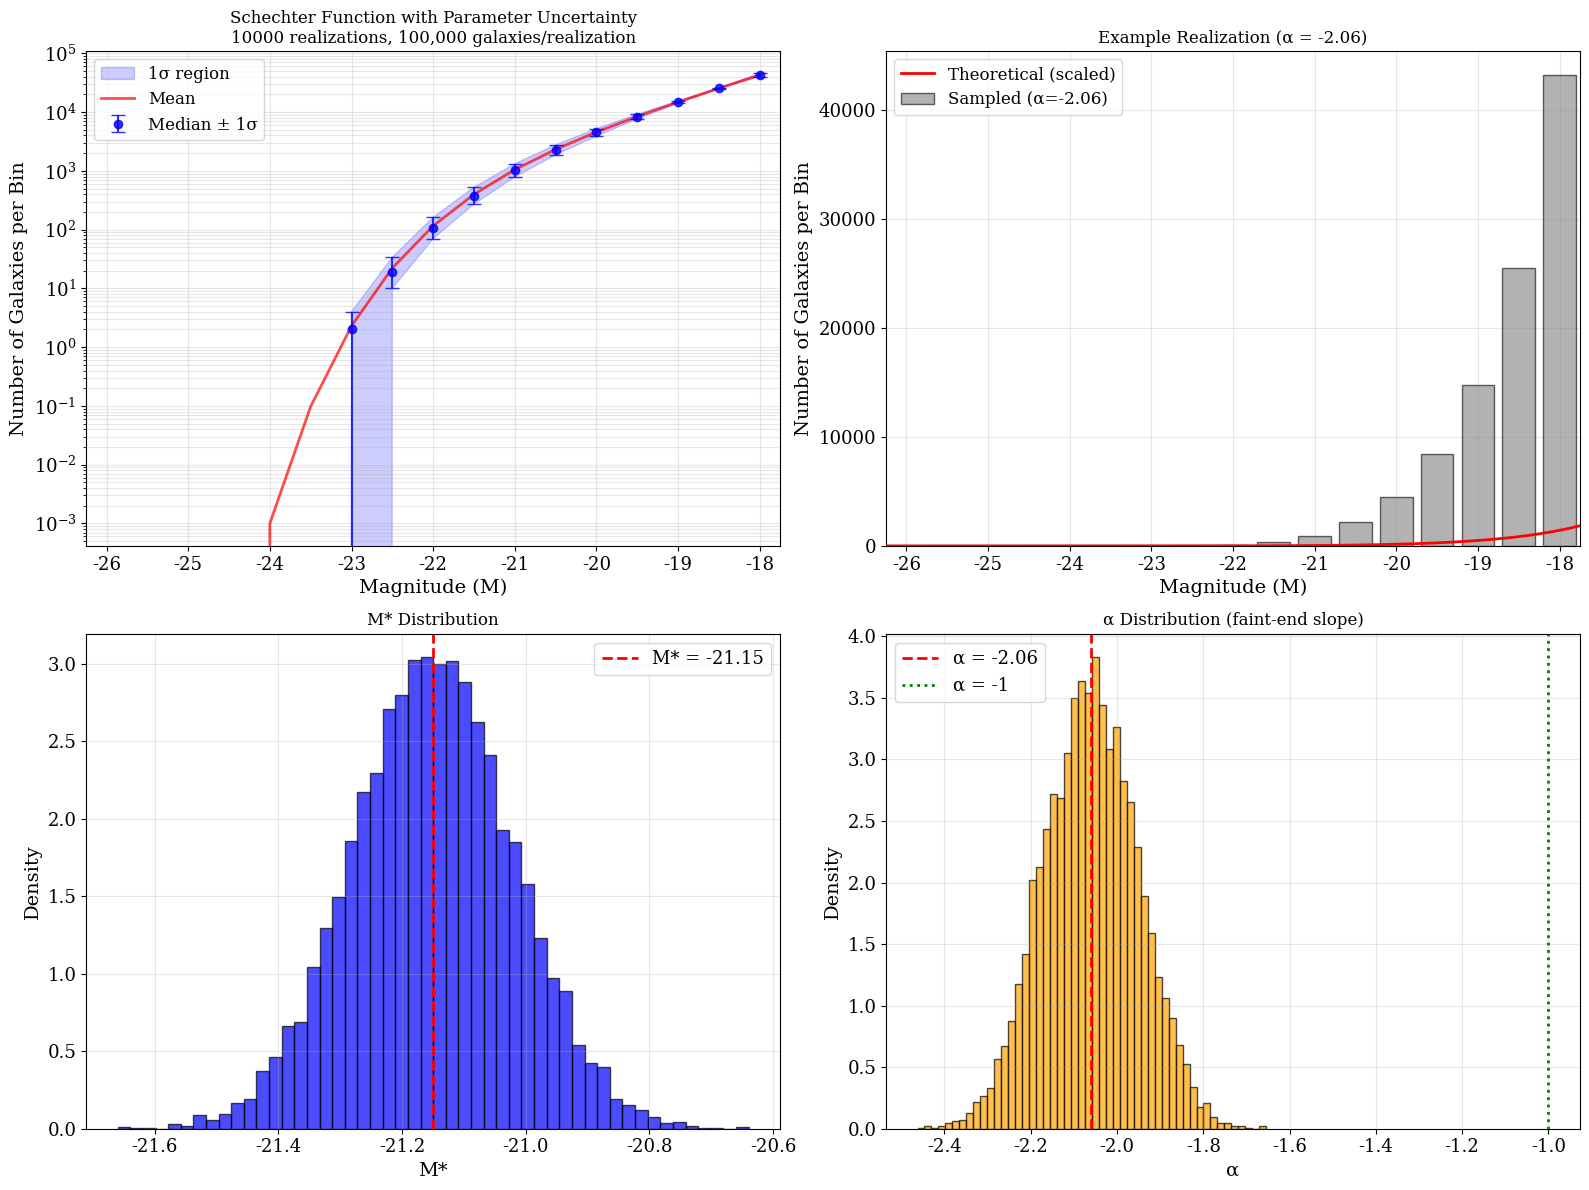

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Binned counts with uncertainty
ax1 = axes[0, 0]

# Plot median with error bars
ax1.errorbar(bin_centers, median_counts,
             yerr=[median_counts - lower_1sigma, upper_1sigma - median_counts],
             fmt='o', color='blue', capsize=5, 
             label='Median ± 1σ', markersize=6, alpha=0.8, zorder=3)

# Fill the 1σ region
ax1.fill_between(bin_centers, lower_1sigma, upper_1sigma, 
                  alpha=0.2, color='blue', label='1σ region')

# Plot mean for comparison
ax1.plot(bin_centers, mean_counts, 'r-', label='Mean', linewidth=2, alpha=0.7)

ax1.set_xlabel('Magnitude (M)', fontsize=14)
ax1.set_ylabel('Number of Galaxies per Bin', fontsize=14)
ax1.set_xlim(magnitude_bins[-1], magnitude_bins[0])
ax1.set_xlim(ax1.get_xlim()[::-1])  # Invert x-axis (brighter on right)
ax1.set_yscale('log')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_title(f'Schechter Function with Parameter Uncertainty\n'
              f'{n_samples} realizations, {n_galaxies_per_realization:,} galaxies/realization', fontsize=12)

# Plot 2: Example realization vs best-fit theoretical
ax2 = axes[0, 1]

# Pick a realization with median α for example
median_alpha_idx = np.argsort(alpha_samples)[len(alpha_samples)//2]
example_counts = bin_counts[median_alpha_idx]

# Plot histogram of example realization
bin_width = magnitude_bins[1] - magnitude_bins[0]
ax2.bar(bin_centers, example_counts, width=bin_width*0.8, 
        alpha=0.6, label=f'Sampled (α={alpha_samples[median_alpha_idx]:.2f})',
        color='gray', edgecolor='black', zorder=2)

# Plot theoretical best-fit curve
M_plot = np.linspace(magnitude_bins[0], magnitude_bins[-1], 500)
x_plot = 10 ** (-0.4 * (M_plot - M_star_guess))
phi_theoretical = phi_star_guess * (x_plot ** (alpha_guess + 1)) * np.exp(-x_plot)

# Scale theoretical to match total counts
total_example = np.sum(example_counts)
theoretical_scaled = phi_theoretical * bin_width * total_example / np.sum(phi_theoretical * bin_width)

ax2.plot(M_plot, theoretical_scaled, 'r-', linewidth=2, 
         label='Theoretical (scaled)', zorder=3)

ax2.set_xlabel('Magnitude (M)', fontsize=14)
ax2.set_ylabel('Number of Galaxies per Bin', fontsize=14)
ax2.set_xlim(magnitude_bins[-1], magnitude_bins[0])
ax2.set_xlim(ax2.get_xlim()[::-1])
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_title(f'Example Realization (α = {alpha_samples[median_alpha_idx]:.2f})', fontsize=12)

# Plot 3: Parameter distributions
ax3 = axes[1, 0]

ax3.hist(M_star_samples, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
ax3.axvline(M_star_guess, color='red', linestyle='--', linewidth=2, label=f'M* = {M_star_guess:.2f}')
ax3.set_xlabel('M*', fontsize=14)
ax3.set_ylabel('Density', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_title('M* Distribution', fontsize=12)

# Plot 4: alpha distribution 
ax4 = axes[1, 1]

ax4.hist(alpha_samples, bins=50, density=True, alpha=0.7, color='orange', edgecolor='black')
ax4.axvline(alpha_guess, color='red', linestyle='--', linewidth=2, label=f'α = {alpha_guess:.2f}')
ax4.axvline(-1, color='green', linestyle=':', linewidth=2, label='α = -1')
# ax4.fill_betweenx([0, ax4.get_ylim()[1]], -10, -1, alpha=0.2, color='red', label='α < -1')
ax4.set_xlabel('α', fontsize=14)
ax4.set_ylabel('Density', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_title('α Distribution (faint-end slope)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Choose a baseline number of galaxies for the best-fit Phi*
# This is arbitrary - it sets the overall scale
baseline_galaxies = 100000

# Store bin counts for each Monte Carlo realization
bin_counts = np.zeros((n_samples, n_bins))

print("Sampling galaxies for each parameter realization...")
print(f"Total realizations: {n_samples}")
print(f"Baseline galaxies (at φ*_guess = {phi_star_guess:.2e}): {baseline_galaxies:,}")
print("-" * 70)

# For each Monte Carlo parameter realization
for i in range(n_samples):
    # Scale the number of galaxies by φ*_sample / φ*_guess
    phi_scale_factor = phi_star_samples[i] / phi_star_guess
    n_galaxies_this_realization = int(baseline_galaxies * phi_scale_factor)
    
    # Ensure at least 1 galaxy (for very small φ*)
    n_galaxies_this_realization = max(1, n_galaxies_this_realization)
    
    # Sample magnitudes using the current parameters and scaled galaxy count
    M_samples = sample_from_schechter(
        n_galaxies_this_realization,
        M_star_samples[i],
        alpha_samples[i],
        M_min=magnitude_bins[0],
        M_max=magnitude_bins[-1]
    )
    
    # Count galaxies in each magnitude bin
    counts, _ = np.histogram(M_samples, bins=magnitude_bins)
    bin_counts[i, :] = counts
    
    # Progress indicator
    if (i + 1) % 1000 == 0:
        print(f"Processed {i+1}/{n_samples} realizations...")
        print(f"  φ* = {phi_star_samples[i]:.2e}, scale factor = {phi_scale_factor:.2f}, "
              f"galaxies = {n_galaxies_this_realization:,}")

print("\n" + "-" * 70)
print("Sampling complete!")
print(f"Average galaxies per realization: {np.mean(np.sum(bin_counts, axis=1)):.0f}")
print(f"Min/Max galaxies: {np.min(np.sum(bin_counts, axis=1)):.0f} / {np.max(np.sum(bin_counts, axis=1)):.0f}")

# Also show the φ* distribution effect
print("\nPhi* scaling effect:")
print(f"Phi*_guess: {phi_star_guess:.2e} -> {baseline_galaxies:,} galaxies")
print(f"Phi*_mean: {phi_star_samples.mean():.2e} -> {int(baseline_galaxies * phi_star_samples.mean() / phi_star_guess):,} galaxies (mean)")
print(f"Phi*_min: {phi_star_samples.min():.2e} -> {int(baseline_galaxies * phi_star_samples.min() / phi_star_guess):,} galaxies")
print(f"Phi*_max: {phi_star_samples.max():.2e} -> {int(baseline_galaxies * phi_star_samples.max() / phi_star_guess):,} galaxies")

Sampling galaxies for each parameter realization...
Total realizations: 10000
Baseline galaxies (at φ*_guess = 1.90e-04): 100,000
----------------------------------------------------------------------
Processed 1000/10000 realizations...
  φ* = 1.67e-04, scale factor = 0.88, galaxies = 88,008
Processed 2000/10000 realizations...
  φ* = 1.14e-04, scale factor = 0.60, galaxies = 60,155
Processed 3000/10000 realizations...
  φ* = 9.15e-05, scale factor = 0.48, galaxies = 48,169
Processed 4000/10000 realizations...
  φ* = 1.99e-04, scale factor = 1.05, galaxies = 104,511
Processed 5000/10000 realizations...
  φ* = 1.78e-04, scale factor = 0.94, galaxies = 93,524
Processed 6000/10000 realizations...
  φ* = 2.35e-04, scale factor = 1.24, galaxies = 123,797
Processed 7000/10000 realizations...
  φ* = 2.14e-04, scale factor = 1.12, galaxies = 112,418
Processed 8000/10000 realizations...
  φ* = 2.73e-04, scale factor = 1.43, galaxies = 143,428
Processed 9000/10000 realizations...
  φ* = 1.83e-0

In [64]:
# Calculate statistics across all realizations
mean_counts = np.mean(bin_counts, axis=0)
median_counts = np.median(bin_counts, axis=0)
lower_1sigma = np.percentile(bin_counts, 16, axis=0)
upper_1sigma = np.percentile(bin_counts, 84, axis=0)
std_counts = np.std(bin_counts, axis=0)
percentile_84 = np.percentile(bin_counts, 84, axis=0)
percentile_16 = np.percentile(bin_counts, 16, axis=0)

# Convert to number density if you have survey volume
# survey_volume = 1e6  # Mpc^3 - replace with actual volume
# bin_width = magnitude_bins[1] - magnitude_bins[0]
# number_density = bin_counts / survey_volume / bin_width

print("\n" + "="*90)
print(f"{'Bin Center':>12} {'Mean':>12} {'Median':>12} {'16th %ile':>12} {'84th %ile':>12} {'Std Dev':>12}")
print("="*90)

for i in range(n_bins):
    print(f"{bin_centers[i]:>12.2f} "
          f"{mean_counts[i]:>12.1f} "
          f"{median_counts[i]:>12.1f} "
          f"{lower_1sigma[i]:>12.1f} "
          f"{upper_1sigma[i]:>12.1f} "
          f"{std_counts[i]:>12.1f} "
    )

# Save results
output_data = np.column_stack([
    bin_centers,
    mean_counts,
    median_counts,
    lower_1sigma,
    upper_1sigma,
    std_counts
])


  Bin Center         Mean       Median    16th %ile    84th %ile      Std Dev
      -26.00          0.0          0.0          0.0          0.0          0.0 
      -25.50          0.0          0.0          0.0          0.0          0.0 
      -25.00          0.0          0.0          0.0          0.0          0.0 
      -24.50          0.0          0.0          0.0          0.0          0.0 
      -24.00          0.0          0.0          0.0          0.0          0.0 
      -23.50          0.1          0.0          0.0          0.0          0.3 
      -23.00          2.3          2.0          0.0          4.0          2.7 
      -22.50         22.4         18.0          8.0         37.0         17.2 
      -22.00        117.0        103.0         52.0        182.0         73.3 
      -21.50        403.0        368.0        197.0        608.2        222.9 
      -21.00       1060.7        997.0        554.0       1577.0        535.9 
      -20.50       2340.3       2245.0       1279.0 

/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_71914/2169672395.py:51: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  phi_theoretical_norm = phi_theoretical / np.trapz(phi_theoretical, M_plot)


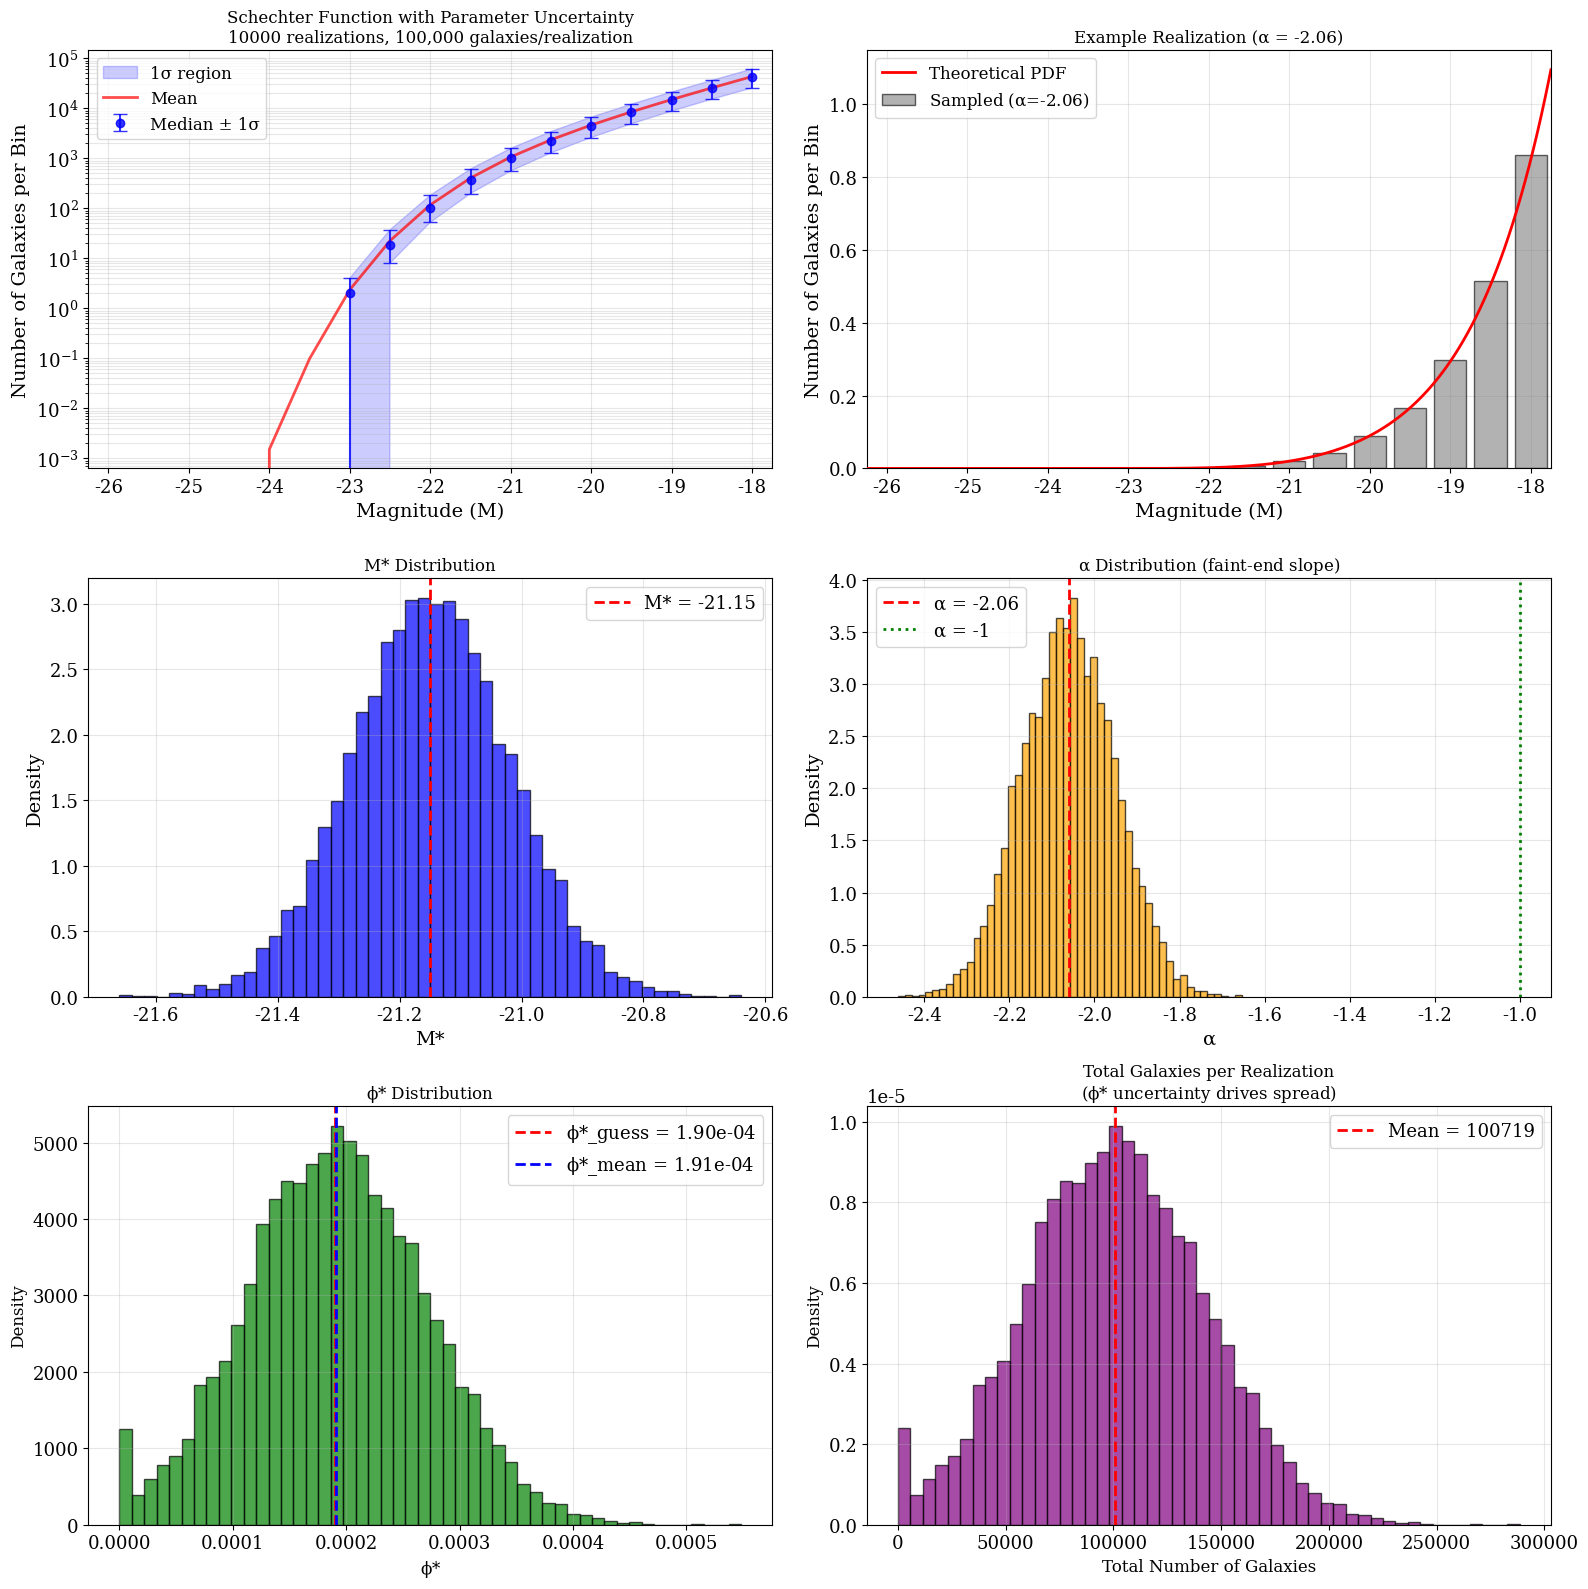

In [82]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))

# Plot 1: Binned counts with uncertainty
ax1 = axes[0, 0]

# Plot median with error bars
ax1.errorbar(bin_centers, median_counts,
             yerr=[median_counts - lower_1sigma, upper_1sigma - median_counts],
             fmt='o', color='blue', capsize=5, 
             label='Median ± 1σ', markersize=6, alpha=0.8, zorder=3)

# Fill the 1σ region
ax1.fill_between(bin_centers, lower_1sigma, upper_1sigma, 
                  alpha=0.2, color='blue', label='1σ region')

# Plot mean for comparison
ax1.plot(bin_centers, mean_counts, 'r-', label='Mean', linewidth=2, alpha=0.7)

ax1.set_xlabel('Magnitude (M)', fontsize=14)
ax1.set_ylabel('Number of Galaxies per Bin', fontsize=14)
ax1.set_xlim(magnitude_bins[-1], magnitude_bins[0])
ax1.set_xlim(ax1.get_xlim()[::-1])  # Invert x-axis (brighter on right)
ax1.set_yscale('log')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_title(f'Schechter Function with Parameter Uncertainty\n'
              f'{n_samples} realizations, {n_galaxies_per_realization:,} galaxies/realization', fontsize=12)

# Plot 2: Example realization vs best-fit theoretical
ax2 = axes[0, 1]

median_alpha_idx = np.argsort(alpha_samples)[len(alpha_samples)//2]
example_counts = bin_counts[median_alpha_idx]
bin_width = magnitude_bins[1] - magnitude_bins[0]

# Convert sampled counts to probability density (area = 1)
total_example = np.sum(example_counts)
example_density = example_counts / (total_example * bin_width)

# Plot as step or bar
ax2.bar(bin_centers, example_density, width=bin_width*0.8, 
        alpha=0.6, label=rf'Sampled ($\alpha$={alpha_samples[median_alpha_idx]:.2f})',
        color='gray', edgecolor='black', zorder=2)

# Plot theoretical PDF (already normalized to area = 1)
M_plot = np.linspace(magnitude_bins[0], magnitude_bins[-1], 500)
x_plot = 10 ** (-0.4 * (M_plot - M_star_guess))
phi_theoretical = phi_star_guess * (x_plot ** (alpha_guess + 1)) * np.exp(-x_plot)

# Normalize theoretical to area = 1
phi_theoretical_norm = phi_theoretical / np.trapz(phi_theoretical, M_plot)

ax2.plot(M_plot, phi_theoretical_norm, 'r-', linewidth=2, 
         label='Theoretical PDF', zorder=3)


ax2.set_xlabel('Magnitude (M)', fontsize=14)
ax2.set_ylabel('Number of Galaxies per Bin', fontsize=14)
ax2.set_xlim(magnitude_bins[-1], magnitude_bins[0])
ax2.set_xlim(ax2.get_xlim()[::-1])
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_title(f'Example Realization (α = {alpha_samples[median_alpha_idx]:.2f})', fontsize=12)

# Plot 3: Parameter distributions
ax3 = axes[1, 0]

ax3.hist(M_star_samples, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
ax3.axvline(M_star_guess, color='red', linestyle='--', linewidth=2, label=f'M* = {M_star_guess:.2f}')
ax3.set_xlabel('M*', fontsize=14)
ax3.set_ylabel('Density', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_title('M* Distribution', fontsize=12)

# Plot 4: alpha distribution 
ax4 = axes[1, 1]

ax4.hist(alpha_samples, bins=50, density=True, alpha=0.7, color='orange', edgecolor='black')
ax4.axvline(alpha_guess, color='red', linestyle='--', linewidth=2, label=f'α = {alpha_guess:.2f}')
ax4.axvline(-1, color='green', linestyle=':', linewidth=2, label='α = -1')
# ax4.fill_betweenx([0, ax4.get_ylim()[1]], -10, -1, alpha=0.2, color='red', label='α < -1')
ax4.set_xlabel(r'$\alpha$', fontsize=14)
ax4.set_ylabel('Density', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_title(r'$\alpha$ Distribution (faint-end slope)', fontsize=12)


# Plot 6: Distribution of φ*
ax5 = axes[2, 0]
ax5.hist(phi_star_samples, bins=50, density=True, alpha=0.7, color='green', edgecolor='black')
ax5.axvline(phi_star_guess, color='red', linestyle='--', linewidth=2, 
            label=rf'$\phi$*_guess = {phi_star_guess:.2e}')
ax5.axvline(phi_star_samples.mean(), color='blue', linestyle='--', linewidth=2,
            label=rf'$\phi$*_mean = {phi_star_samples.mean():.2e}')
ax5.set_xlabel(r'$\phi$*', fontsize=12)
ax5.set_ylabel('Density', fontsize=12)
ax5.set_title(r'$\phi$* Distribution', fontsize=12)
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 3: Distribution of total counts (affected by φ*)
total_counts = np.sum(bin_counts, axis=1)
ax6 = axes[2, 1]
ax6.hist(total_counts, bins=50, density=True, alpha=0.7, color='purple', edgecolor='black')
ax6.axvline(np.mean(total_counts), color='red', linestyle='--', linewidth=2,
            label=f'Mean = {np.mean(total_counts):.0f}')
ax6.set_xlabel('Total Number of Galaxies', fontsize=12)
ax6.set_ylabel('Density', fontsize=12)
ax6.set_title('Total Galaxies per Realization\n' + r'($\phi$* uncertainty drives spread)', fontsize=12)
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

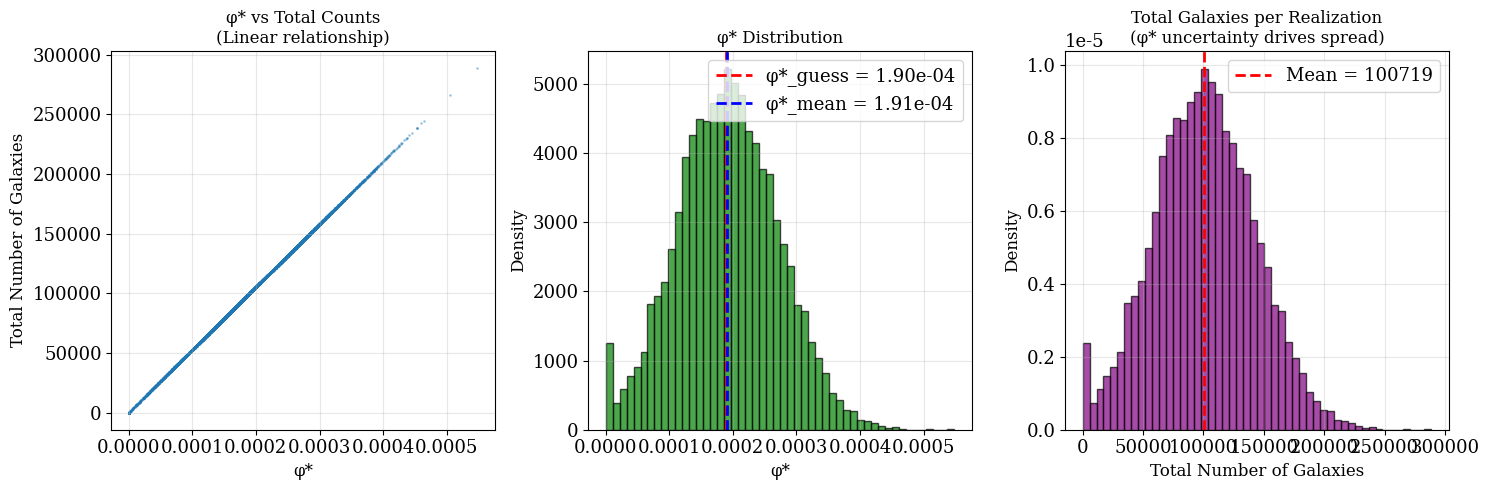


IMPACT OF φ* UNCERTAINTY
φ* relative uncertainty: 42.1%
Total counts relative spread: 41.4%

Correlation between φ* and total counts: 1.000


In [26]:
# Calculate total counts per realization (now varies with φ*)
total_counts = np.sum(bin_counts, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: φ* vs total counts (should show linear relationship)
ax1 = axes[0]
ax1.scatter(phi_star_samples, total_counts, alpha=0.3, s=1)
ax1.set_xlabel('φ*', fontsize=12)
ax1.set_ylabel('Total Number of Galaxies', fontsize=12)
ax1.set_title('φ* vs Total Counts\n(Linear relationship)', fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of φ*
ax2 = axes[1]
ax2.hist(phi_star_samples, bins=50, density=True, alpha=0.7, color='green', edgecolor='black')
ax2.axvline(phi_star_guess, color='red', linestyle='--', linewidth=2, 
            label=f'φ*_guess = {phi_star_guess:.2e}')
ax2.axvline(phi_star_samples.mean(), color='blue', linestyle='--', linewidth=2,
            label=f'φ*_mean = {phi_star_samples.mean():.2e}')
ax2.set_xlabel('φ*', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('φ* Distribution', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Distribution of total counts (affected by φ*)
ax3 = axes[2]
ax3.hist(total_counts, bins=50, density=True, alpha=0.7, color='purple', edgecolor='black')
ax3.axvline(np.mean(total_counts), color='red', linestyle='--', linewidth=2,
            label=f'Mean = {np.mean(total_counts):.0f}')
ax3.set_xlabel('Total Number of Galaxies', fontsize=12)
ax3.set_ylabel('Density', fontsize=12)
ax3.set_title('Total Galaxies per Realization\n(φ* uncertainty drives spread)', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*60)
print("IMPACT OF φ* UNCERTAINTY")
print("="*60)
print(f"φ* relative uncertainty: {phi_star_err / phi_star_guess * 100:.1f}%")
print(f"Total counts relative spread: {np.std(total_counts) / np.mean(total_counts) * 100:.1f}%")
print(f"\nCorrelation between φ* and total counts: {np.corrcoef(phi_star_samples, total_counts)[0,1]:.3f}")

### Phi* cancels out of CDF

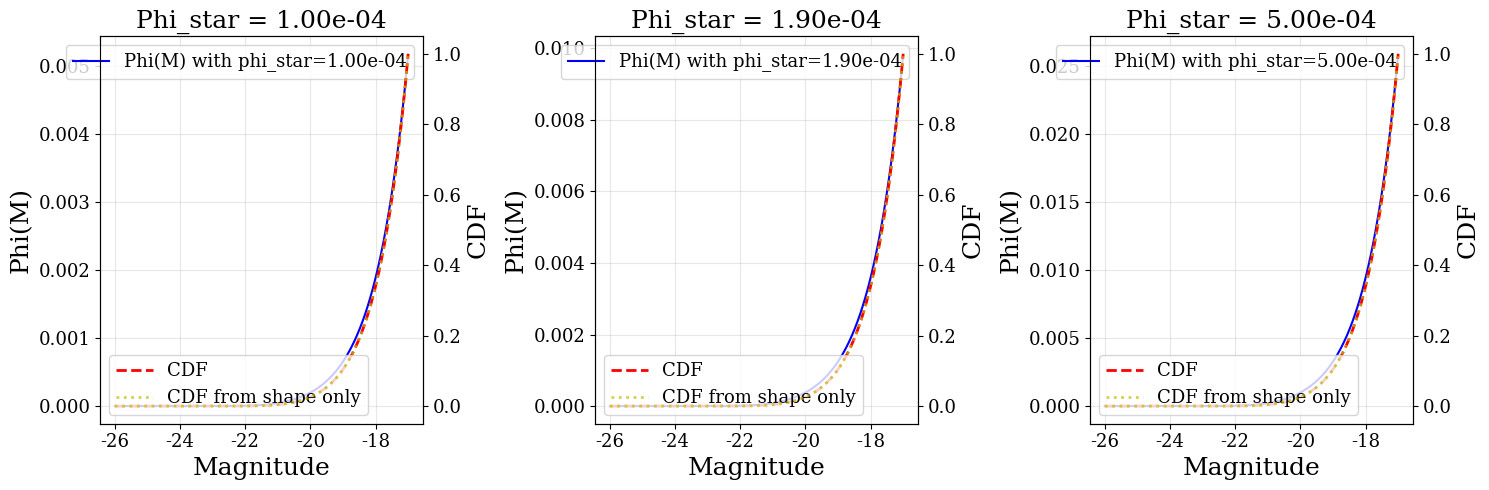


VERIFICATION: Are all CDFs identical?
Max difference between Phi*=0.1e-3 and Phi*=0.19e-3: 6.66e-16
Max difference between Phi*=0.1e-3 and Phi*=0.5e-3: 4.44e-16


In [83]:
# PROVING PHI_STAR ISN'T NEEDED FOR SAMPLING CDF

# Define the shape function (without φ*)
def schechter_shape(M, M_star, alpha):
    x = 10 ** (-0.4 * (M - M_star))
    return 0.4 * np.log(10) * (x ** (alpha + 1)) * np.exp(-x)

# Same M* and α, different phi* values
M_star = -21.15
alpha = -2.06
phi_star_values = [0.1e-3, 0.19e-3, 0.5e-3]  # Different normalizations

M_grid = np.linspace(-26, -17, 1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, phi_star in enumerate(phi_star_values):
    # Full Schechter with phi_star
    phi_full = phi_star * schechter_shape(M_grid, M_star, alpha)
    
    # Compute CDF for full function
    cdf_full = cumulative_trapezoid(phi_full, M_grid, initial=0)
    cdf_full = cdf_full / cdf_full[-1]
    
    # Compute CDF for shape only (without phi_star)
    phi_shape = schechter_shape(M_grid, M_star, alpha)
    cdf_shape = cumulative_trapezoid(phi_shape, M_grid, initial=0)
    cdf_shape = cdf_shape / cdf_shape[-1]
    
    # Plot
    ax = axes[idx]
    ax.plot(M_grid, phi_full, 'b-', label=f'Phi(M) with phi_star={phi_star:.2e}')
    ax.set_xlabel('Magnitude')
    ax.set_ylabel('Phi(M)')
    ax.set_title(f'Phi_star = {phi_star:.2e}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Create twin axis for CDF
    ax2 = ax.twinx()
    ax2.plot(M_grid, cdf_full, 'r--', label='CDF', linewidth=2)
    ax2.plot(M_grid, cdf_shape, 'y:', label='CDF from shape only', linewidth=2, alpha=0.7, zorder=10)
    ax2.set_ylabel('CDF')
    ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("VERIFICATION: Are all CDFs identical?")
print("="*60)

# Check if CDFs are the same regardless of φ*
phi_full_1 = phi_star_values[0] * schechter_shape(M_grid, M_star, alpha)
phi_full_2 = phi_star_values[1] * schechter_shape(M_grid, M_star, alpha)
phi_full_3 = phi_star_values[2] * schechter_shape(M_grid, M_star, alpha)

cdf1 = cumulative_trapezoid(phi_full_1, M_grid, initial=0)
cdf2 = cumulative_trapezoid(phi_full_2, M_grid, initial=0)
cdf3 = cumulative_trapezoid(phi_full_3, M_grid, initial=0)

cdf1 = cdf1 / cdf1[-1]
cdf2 = cdf2 / cdf2[-1]
cdf3 = cdf3 / cdf3[-1]

print(f"Max difference between Phi*=0.1e-3 and Phi*=0.19e-3: {np.max(np.abs(cdf1 - cdf2)):.2e}")
print(f"Max difference between Phi*=0.1e-3 and Phi*=0.5e-3: {np.max(np.abs(cdf1 - cdf3)):.2e}")


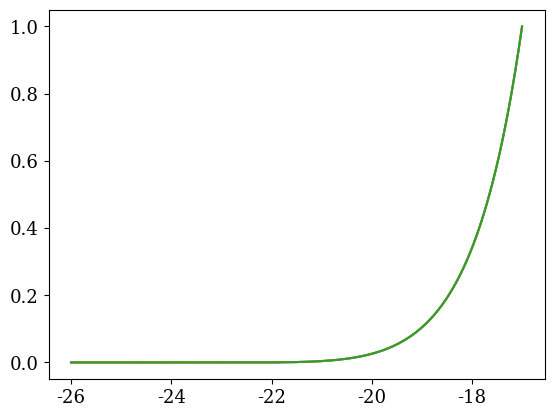

In [72]:
plt.plot(M_grid, cdf1)
plt.plot(M_grid, cdf2)
plt.plot(M_grid, cdf3)

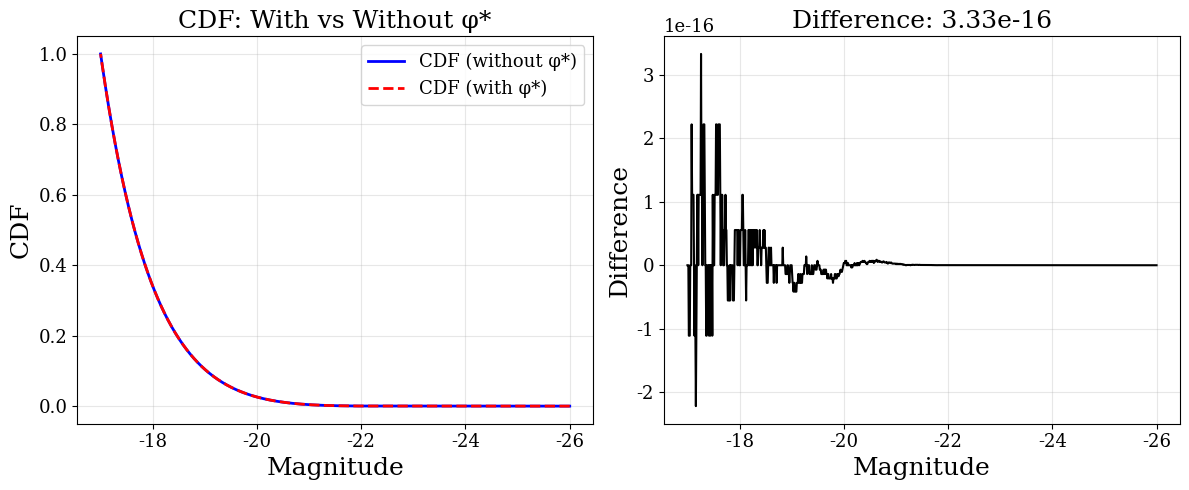


Maximum difference between CDFs: 3.33e-16
✅ They are identical to within numerical precision!


In [29]:
# Compute CDFs with and without φ*
phi_star_test = 0.19e-3

# Method 1: Your function (without φ*)
x_grid = 10 ** (-0.4 * (M_grid - M_star))
phi_no_phi = x_grid ** (alpha + 1) * np.exp(-x_grid)
cdf_no_phi = cumulative_trapezoid(phi_no_phi, M_grid, initial=0)
cdf_no_phi = cdf_no_phi / cdf_no_phi[-1]

# Method 2: With φ*
phi_with_phi = phi_star_test * 0.4 * np.log(10) * x_grid ** (alpha + 1) * np.exp(-x_grid)
cdf_with_phi = cumulative_trapezoid(phi_with_phi, M_grid, initial=0)
cdf_with_phi = cdf_with_phi / cdf_with_phi[-1]

# Compare
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(M_grid, cdf_no_phi, 'b-', label='CDF (without φ*)', linewidth=2)
ax1.plot(M_grid, cdf_with_phi, 'r--', label='CDF (with φ*)', linewidth=2)
ax1.set_xlabel('Magnitude')
ax1.set_ylabel('CDF')
ax1.set_title('CDF: With vs Without φ*')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()

ax2.plot(M_grid, cdf_no_phi - cdf_with_phi, 'k-')
ax2.set_xlabel('Magnitude')
ax2.set_ylabel('Difference')
ax2.set_title(f'Difference: {np.max(np.abs(cdf_no_phi - cdf_with_phi)):.2e}')
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

print(f"\nMaximum difference between CDFs: {np.max(np.abs(cdf_no_phi - cdf_with_phi)):.2e}")
print("✅ They are identical to within numerical precision!")

In [84]:
def power_law_softening(L, L0, exponent=1.0, max_prob=1.0):
    """
    Power law softening function.
    p_split = max_prob * (L/L0)^exponent for L > L0, 0 otherwise
    """
    p = np.zeros_like(L, dtype=float)
    mask = L > L0
    p[mask] = max_prob * (L[mask] / L0) ** exponent
    return np.clip(p, 0, max_prob)

def sigmoid_softening(L, L0, sharpness=1.0, max_prob=1.0):
    """
    Sigmoid softening function.
    p_split = max_prob / (1 + exp(-sharpness * (L - L0)))
    """
    return max_prob / (1 + np.exp(-sharpness * (L - L0)))

def exponential_softening(L, L0, decay_length=1.0, max_prob=1.0):
    """
    Exponential softening function.
    p_split = max_prob * exp(-(L0 - L)/decay_length) for L < L0, 
              max_prob for L >= L0
    """
    p = np.zeros_like(L, dtype=float)
    mask_below = L < L0
    mask_above = L >= L0
    p[mask_below] = max_prob * np.exp(-(L0 - L[mask_below]) / decay_length)
    p[mask_above] = max_prob
    return np.clip(p, 0, max_prob)

def threshold_softening(L, L0, max_prob=1.0):
    """
    Simple threshold: split only galaxies above L0 with fixed probability.
    """
    p = np.zeros_like(L, dtype=float)
    p[L > L0] = max_prob
    return p

def linear_softening(L, L0, L1, max_prob=1.0):
    """
    Linear softening: increases linearly from 0 at L0 to max_prob at L1.
    """
    p = np.zeros_like(L, dtype=float)
    mask_mid = (L >= L0) & (L <= L1)
    mask_high = L > L1
    p[mask_mid] = max_prob * (L[mask_mid] - L0) / (L1 - L0)
    p[mask_high] = max_prob
    return np.clip(p, 0, max_prob)

<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:45: SyntaxWarning: invalid escape sequence '\o'
<>:59: SyntaxWarning: invalid escape sequence '\o'
<>:73: SyntaxWarning: invalid escape sequence '\o'
<>:101: SyntaxWarning: invalid escape sequence '\o'
<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:45: SyntaxWarning: invalid escape sequence '\o'
<>:59: SyntaxWarning: invalid escape sequence '\o'
<>:73: SyntaxWarning: invalid escape sequence '\o'
<>:101: SyntaxWarning: invalid escape sequence '\o'
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_71914/494170176.py:17: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('Luminosity (L$_\odot$)', fontsize=12)
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_71914/494170176.py:31: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('Luminosity (L$_\odot$)', fontsize=12)
/var/folders/k7/1njpygzx

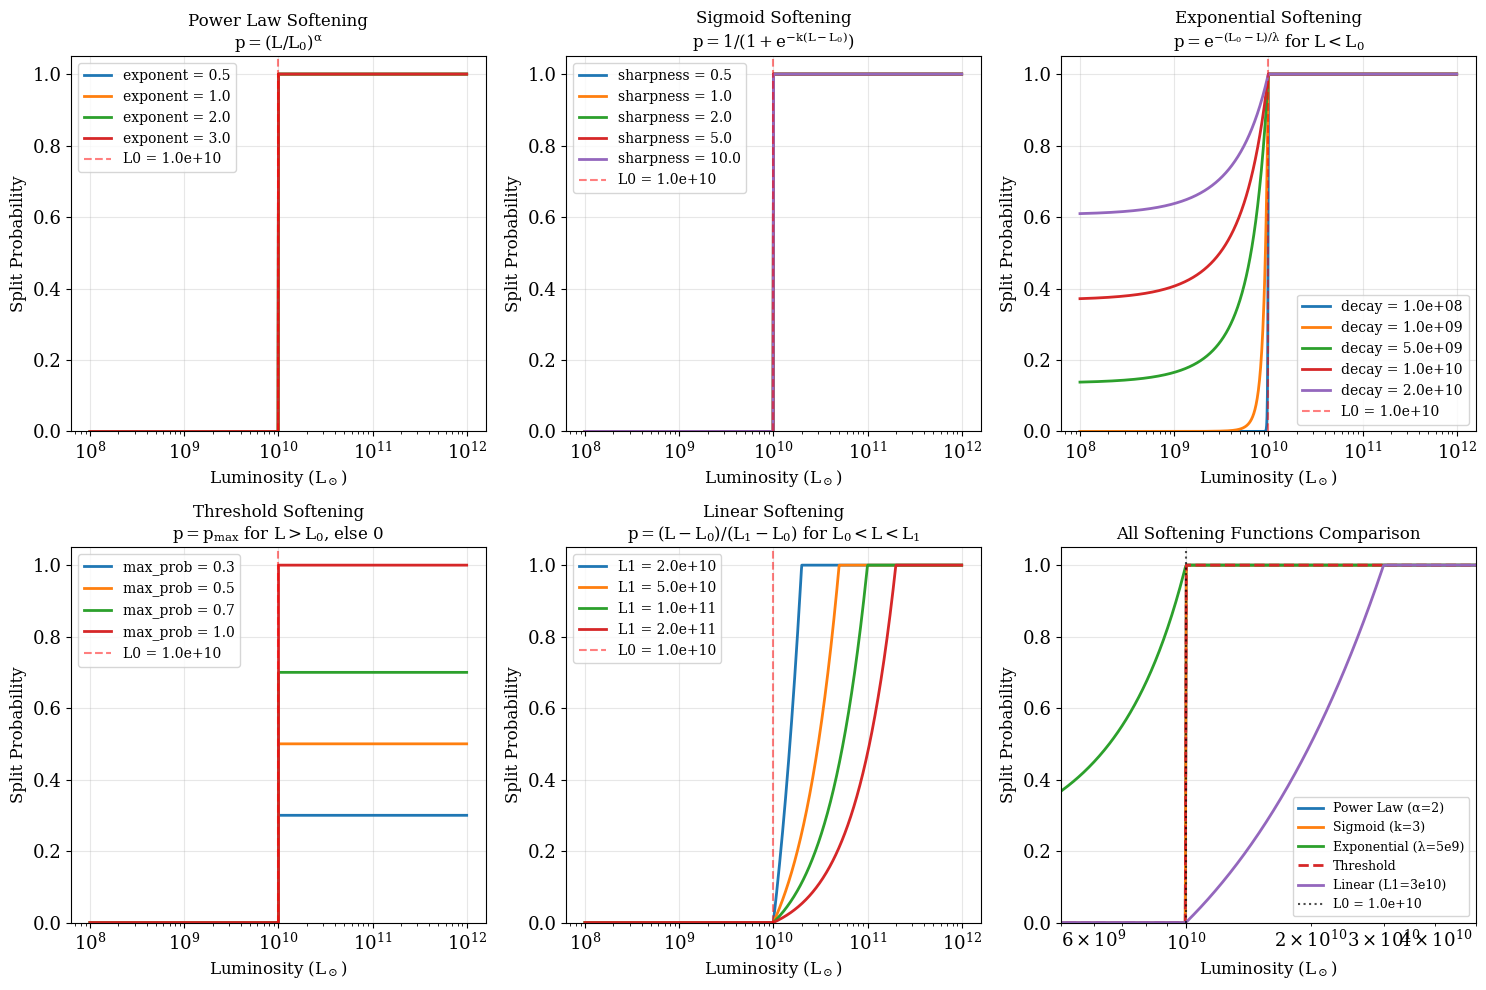

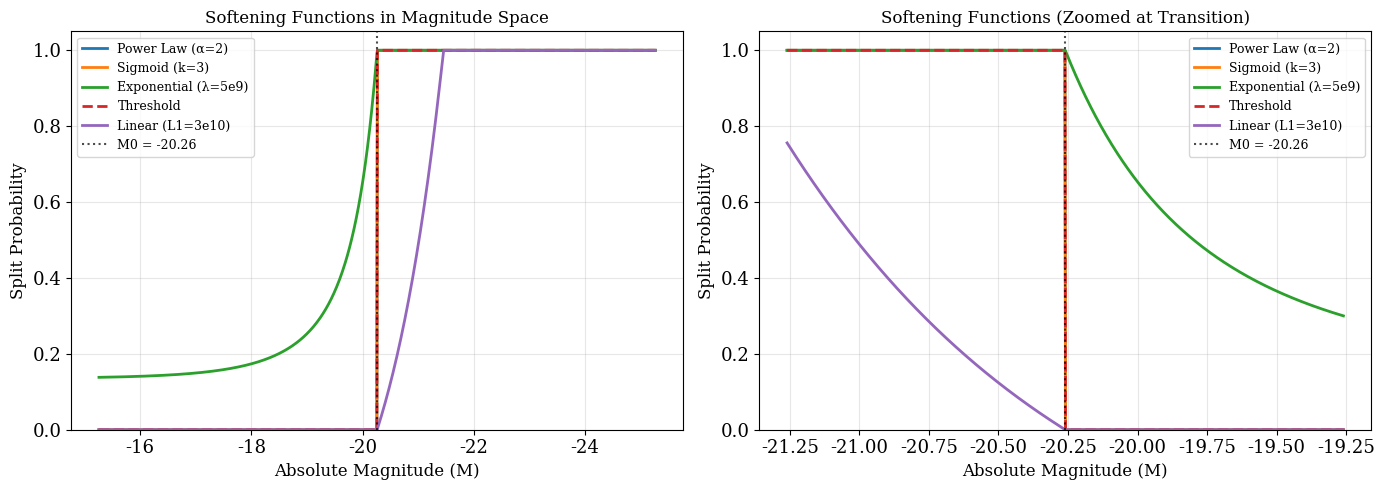

In [85]:
# Create luminosity range (log scale from 1e8 to 1e12 L_sun)
L_range = np.logspace(8, 12, 1000)
L0 = 1e10  # Threshold luminosity
max_prob = 1.0

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# 1. Power Law (different exponents)
ax = axes[0]
for exponent in [0.5, 1.0, 2.0, 3.0]:
    p = power_law_softening(L_range, L0, exponent=exponent, max_prob=max_prob)
    ax.plot(L_range, p, label=f'exponent = {exponent}', linewidth=2)
ax.axvline(L0, color='red', linestyle='--', alpha=0.5, label=f'L0 = {L0:.1e}')
ax.set_xscale('log')
ax.set_xlabel('Luminosity (L$_\odot$)', fontsize=12)
ax.set_ylabel('Split Probability', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Power Law Softening\n$p = (L/L_0)^{\\alpha}$', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# 2. Sigmoid (different sharpness)
ax = axes[1]
for sharpness in [0.5, 1.0, 2.0, 5.0, 10.0]:
    p = sigmoid_softening(L_range, L0, sharpness=sharpness, max_prob=max_prob)
    ax.plot(L_range, p, label=f'sharpness = {sharpness}', linewidth=2)
ax.axvline(L0, color='red', linestyle='--', alpha=0.5, label=f'L0 = {L0:.1e}')
ax.set_xscale('log')
ax.set_xlabel('Luminosity (L$_\odot$)', fontsize=12)
ax.set_ylabel('Split Probability', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Sigmoid Softening\n$p = 1/(1 + e^{-k(L-L_0)})$', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# 3. Exponential (different decay lengths)
ax = axes[2]
for decay_length in [1e8, 1e9, 5e9, 1e10, 2e10]:
    p = exponential_softening(L_range, L0, decay_length=decay_length, max_prob=max_prob)
    ax.plot(L_range, p, label=f'decay = {decay_length:.1e}', linewidth=2)
ax.axvline(L0, color='red', linestyle='--', alpha=0.5, label=f'L0 = {L0:.1e}')
ax.set_xscale('log')
ax.set_xlabel('Luminosity (L$_\odot$)', fontsize=12)
ax.set_ylabel('Split Probability', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Exponential Softening\n$p = e^{-(L_0-L)/\\lambda}$ for $L<L_0$', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# 4. Threshold (different max_prob)
ax = axes[3]
for prob in [0.3, 0.5, 0.7, 1.0]:
    p = threshold_softening(L_range, L0, max_prob=prob)
    ax.plot(L_range, p, label=f'max_prob = {prob}', linewidth=2, drawstyle='steps-post')
ax.axvline(L0, color='red', linestyle='--', alpha=0.5, label=f'L0 = {L0:.1e}')
ax.set_xscale('log')
ax.set_xlabel('Luminosity (L$_\odot$)', fontsize=12)
ax.set_ylabel('Split Probability', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Threshold Softening\n$p = p_{max}$ for $L > L_0$, else 0', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# 5. Linear (different transition ranges)
ax = axes[4]
for L1 in [2e10, 5e10, 1e11, 2e11]:
    p = linear_softening(L_range, L0, L1, max_prob=max_prob)
    ax.plot(L_range, p, label=f'L1 = {L1:.1e}', linewidth=2)
ax.axvline(L0, color='red', linestyle='--', alpha=0.5, label=f'L0 = {L0:.1e}')
ax.set_xscale('log')
ax.set_xlabel('Luminosity (L$_\odot$)', fontsize=12)
ax.set_ylabel('Split Probability', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Linear Softening\n$p = (L-L_0)/(L_1-L_0)$ for $L_0<L<L_1$', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# 6. Comparison of all functions with default parameters
ax = axes[5]
L_range_plot = np.logspace(9, 11.5, 1000)  # Zoom in on transition region

# Default parameters
L0_compare = 1e10
max_prob_compare = 1.0

ax.plot(L_range_plot, power_law_softening(L_range_plot, L0_compare, exponent=2.0, max_prob=max_prob_compare),
        label='Power Law (α=2)', linewidth=2)
ax.plot(L_range_plot, sigmoid_softening(L_range_plot, L0_compare, sharpness=3.0, max_prob=max_prob_compare),
        label='Sigmoid (k=3)', linewidth=2)
ax.plot(L_range_plot, exponential_softening(L_range_plot, L0_compare, decay_length=5e9, max_prob=max_prob_compare),
        label='Exponential (λ=5e9)', linewidth=2)
ax.plot(L_range_plot, threshold_softening(L_range_plot, L0_compare, max_prob=max_prob_compare),
        label='Threshold', linewidth=2, linestyle='--')
ax.plot(L_range_plot, linear_softening(L_range_plot, L0_compare, L1=3e10, max_prob=max_prob_compare),
        label='Linear (L1=3e10)', linewidth=2)

ax.axvline(L0_compare, color='black', linestyle=':', alpha=0.7, label=f'L0 = {L0_compare:.1e}')
ax.set_xscale('log')
ax.set_xlabel('Luminosity (L$_\odot$)', fontsize=12)
ax.set_ylabel('Split Probability', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_xlim(5e9, 5e10)
ax.set_title('All Softening Functions Comparison', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

# Also create a side-by-side comparison in magnitude space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Convert luminosity range to magnitude
M_sun = 4.74
M_range = M_sun - 2.5 * np.log10(L_range)
M0 = M_sun - 2.5 * np.log10(L0)

# Plot in magnitude space
ax1.plot(M_range, power_law_softening(L_range, L0, exponent=2.0, max_prob=max_prob),
         label='Power Law (α=2)', linewidth=2)
ax1.plot(M_range, sigmoid_softening(L_range, L0, sharpness=3.0, max_prob=max_prob),
         label='Sigmoid (k=3)', linewidth=2)
ax1.plot(M_range, exponential_softening(L_range, L0, decay_length=5e9, max_prob=max_prob),
         label='Exponential (λ=5e9)', linewidth=2)
ax1.plot(M_range, threshold_softening(L_range, L0, max_prob=max_prob),
         label='Threshold', linewidth=2, linestyle='--')
ax1.plot(M_range, linear_softening(L_range, L0, L1=3e10, max_prob=max_prob),
         label='Linear (L1=3e10)', linewidth=2)

ax1.axvline(M0, color='black', linestyle=':', alpha=0.7, label=f'M0 = {M0:.2f}')
ax1.set_xlabel('Absolute Magnitude (M)', fontsize=12)
ax1.set_ylabel('Split Probability', fontsize=12)
ax1.set_ylim(0, 1.05)
ax1.invert_xaxis()  # Brighter magnitudes on right
ax1.set_title('Softening Functions in Magnitude Space', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

# Zoom in on transition region
M_range_zoom = np.linspace(M0 - 1, M0 + 1, 1000)
L_range_zoom = 10 ** (-0.4 * (M_range_zoom - M_sun))

ax2.plot(M_range_zoom, power_law_softening(L_range_zoom, L0, exponent=2.0, max_prob=max_prob),
         label='Power Law (α=2)', linewidth=2)
ax2.plot(M_range_zoom, sigmoid_softening(L_range_zoom, L0, sharpness=3.0, max_prob=max_prob),
         label='Sigmoid (k=3)', linewidth=2)
ax2.plot(M_range_zoom, exponential_softening(L_range_zoom, L0, decay_length=5e9, max_prob=max_prob),
         label='Exponential (λ=5e9)', linewidth=2)
ax2.plot(M_range_zoom, threshold_softening(L_range_zoom, L0, max_prob=max_prob),
         label='Threshold', linewidth=2, linestyle='--')
ax2.plot(M_range_zoom, linear_softening(L_range_zoom, L0, L1=3e10, max_prob=max_prob),
         label='Linear (L1=3e10)', linewidth=2)

ax2.axvline(M0, color='black', linestyle=':', alpha=0.7, label=f'M0 = {M0:.2f}')
ax2.set_xlabel('Absolute Magnitude (M)', fontsize=12)
ax2.set_ylabel('Split Probability', fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.set_title('Softening Functions (Zoomed at Transition)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

17


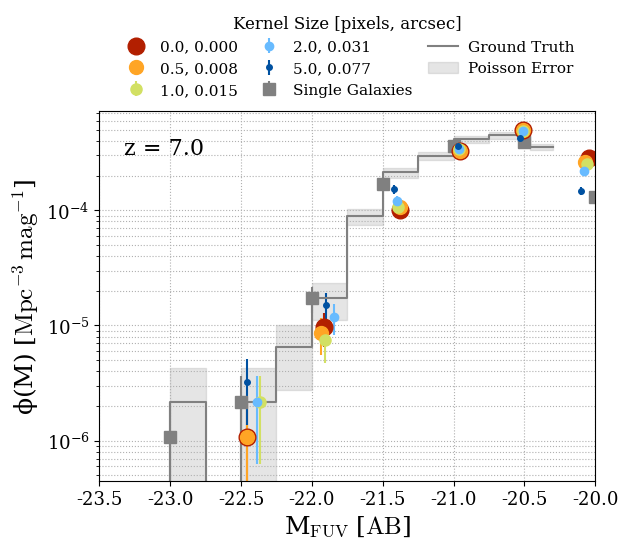

In [27]:
# ---------------- UVLF FOR SPECIFIC THRESHOLD ---------------- #
df = f150w_Table.copy()
fig,ax = plt.subplots()

distance_threshold = 0.15     # pixels
conv_values = [0.0, 0.5, 1.0, 2.0, 5.0]
colors = ['#B21F00','#FFA525','#D2E063','#68BBFF','#0051A1']
sizes = [12,10,8,6,4]

# --- Ground Truth (gray histogram) ---
mask_gt = (df['has_psf'] == False) & (df['convolution'] == 0.0)
lum_FUV_gt = np.log10(df['lumFUV'][mask_gt])
M_FUV_gt = 51.63 - 2.5 * lum_FUV_gt

len_sample = np.sum(mask_nopsf)
len_catalog = len(catalog)
h = 0.7
L_box = 400 / h
V_box = L_box**3
V_eff = V_box * (len_sample / len_catalog)

bins_M = np.arange(-23.75, -14.75, 0.5)  # magnitude bins
bin_centers_M = 0.5 * (bins_M[:-1] + bins_M[1:])
bin_width_M = bins_M[1] - bins_M[0]
print(len(bin_centers_M))

N_gt_M, _ = np.histogram(M_FUV_gt, bins=bins_M)
phi_gt_M = N_gt_M / (V_eff * bin_width_M)
phi_err_gt_M = np.sqrt(N_gt_M)/(V_eff * bin_width_M)

upper = phi_gt_M + phi_err_gt_M
lower = phi_gt_M - phi_err_gt_M

# ----- SINGLE GALAXIES AS ERRORBARS -----
single_gals = ax.errorbar(
    bin_centers_M, phi_gt_M, 
    yerr=phi_err_gt_M,
    fmt='s',
    markersize=8,
    label='Single Galaxies',
    color='gray'
    )


# ----- Loop through all convolution values -----
leg2_handles = []

for idx,conv in enumerate(conv_values):

    mask_psf = (df['has_psf'] == True) & (df['convolution'] == conv)
    dist_psf = df['distance_as'][mask_psf]
    lumFUV_psf = df['lumFUV'][mask_psf]
    flux_ratio_psf = df['flux_ratio'][mask_psf]

    predicted_pair = (dist_psf >= distance_threshold)

    lumFUV_split = []
    for i in range(len(lumFUV_psf)):
        if predicted_pair[i]:
            lumFUV_split.append(lumFUV_psf[i] * flux_ratio_psf[i])
            lumFUV_split.append(lumFUV_psf[i] * (1 - flux_ratio_psf[i]))
        else:
            lumFUV_split.append(lumFUV_psf[i])

    lumFUV_split = np.log10(lumFUV_split)
    M_FUV_pair = 51.63 - 2.5 * np.array(lumFUV_split)

    N_pair_M, _ = np.histogram(M_FUV_pair, bins=bins_M)
    phi_pair_M = N_pair_M / (V_eff * bin_width_M)
    phi_err_pair_M = np.sqrt(N_pair_M) / (V_eff * bin_width_M)

    # --- Compute bin medians ---
    bin_medians_M = []

    for i in range(len(bins_M) - 1):
        in_bin = (M_FUV_pair >= bins_M[i]) & (M_FUV_pair < bins_M[i + 1])
        if np.any(in_bin):
            bin_medians_M.append(np.median(M_FUV_pair[in_bin]))
        else:
            bin_medians_M.append(np.nan)

    bin_medians_M = np.array(bin_medians_M)

    uvlf = ax.errorbar(
        bin_medians_M,  # change to bin_centers_M if desired
        phi_pair_M, 
        yerr=phi_err_pair_M, 
        fmt='o',
        color=colors[idx],
        label=rf'{conv}, {conv*0.0155:.3f}',
        ms=sizes[idx]
        )
    leg2_handles.append(uvlf)
leg2_handles.append(single_gals)

# ----- TRUE SPLIT AS STEP FUNCTION -----
true_split, = ax.step(
    UVLF_SPLIT['bin_centers'], 
    UVLF_SPLIT['phi'],
    where='mid', 
    label='Ground Truth',
    color='gray'
    )
lower = UVLF_SPLIT['phi'] - UVLF_SPLIT['phi_err']   # lower error
upper = UVLF_SPLIT['phi'] + UVLF_SPLIT['phi_err']   # upper error
poisson_err = ax.fill_between(
    UVLF_SPLIT['bin_centers'],
    lower,
    upper,
    step='mid',
    alpha=0.2,
    color='gray',
    label='Poisson Error'
)
leg2_handles.append(true_split)
leg2_handles.append(poisson_err)

# ----- LABEL REDSHIFT OF UVLF -----
ax.annotate(
    'z = 7.0',
    xy=(0.05, 0.9),    # text location
    xycoords='axes fraction',
    fontsize=16,
    ha='left',
    va='center'
)

ax.set_yscale('log')
ax.set_xlabel(r'$M_{\mathrm{FUV}}\ [\mathrm{AB}]$')
ax.set_ylabel(r'$\phi(M)\ [\mathrm{Mpc^{-3}\,mag^{-1}}]$')
# ax.set_title(f'FUV Luminosity Function')
ax.grid(True, which='both', ls=':')
ax.set_xlim(-23.5,-20)

# second legend
leg2 = ax.legend(
    handles=leg2_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    fontsize=11,
    title='Kernel Size [pixels, arcsec]',
    title_fontsize=12,
    handlelength=2,
    handletextpad=0.6,
    columnspacing=1.0,
    markerscale=1,
    frameon=False
)
# ax.add_artist(leg2)

# plt.tight_layout()
plt.show()